## Importing Dependencies

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

## Loading the Data

In [3]:
LETF  = "TSLT"
UNDER = "TSLA"
START = "2023-10-19"
END = "2026-06-11"

raw = yf.download([LETF, UNDER], start=START, end=END, auto_adjust=True, progress=False)

# Select by name, don't rely on column order
px = raw["Close"][[LETF, UNDER]].dropna()

print(f"{len(px)} aligned trading days: {px.index.min().date()} -> {px.index.max().date()}")
px.head()

662 aligned trading days: 2023-10-19 -> 2026-06-10


Ticker,TSLT,TSLA
Date,,
2023-10-19,20.455999,220.110001
2023-10-20,18.892000,211.990005
2023-10-23,18.860001,212.080002
2023-10-24,19.590000,216.520004
2023-10-25,18.889000,212.419998


## Calculating the Emperical Beta

In [5]:
ret    = px.pct_change().dropna()              # simple daily returns
logret = np.log(px / px.shift(1)).dropna()     # log returns (for the A-Z step later)

# Sanity check: TSLT's daily return should be ~2x TSLA's
beta_fit = np.polyfit(ret[UNDER], ret[LETF], 1)[0]
print(f"Empirical daily beta of {LETF} on {UNDER}: {beta_fit:.3f}  (target = 2.0)")

# Annualized volatility
ann_vol = ret.std() * np.sqrt(252)
print("\nAnnualized volatility:")
print(ann_vol.round(3))

ret.head()

Empirical daily beta of TSLT on TSLA: 1.992  (target = 2.0)

Annualized volatility:
Ticker
TSLT    1.172
TSLA    0.588
dtype: float64


Ticker,TSLT,TSLA
Date,,
2023-10-20,-0.076457,-0.036891
2023-10-23,-0.001694,0.000425
2023-10-24,0.038706,0.020936
2023-10-25,-0.035784,-0.018936
2023-10-26,-0.060617,-0.031353


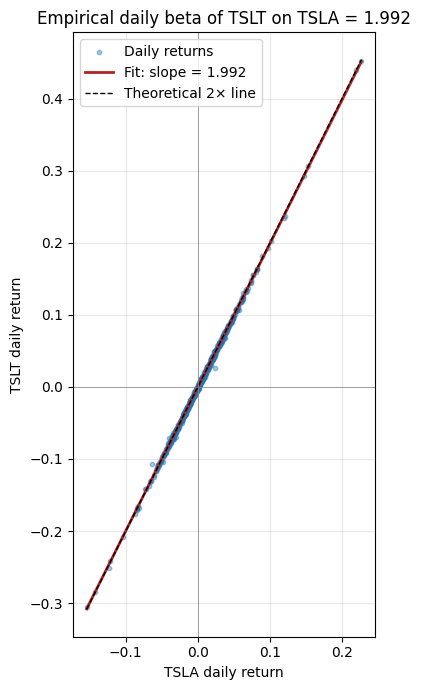

In [6]:
# Recover slope and intercept (your beta_fit only kept the slope)
slope, intercept = np.polyfit(ret[UNDER], ret[LETF], 1)
xs = np.linspace(ret[UNDER].min(), ret[UNDER].max(), 100)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(ret[UNDER], ret[LETF], s=10, alpha=0.4, label="Daily returns")
ax.plot(xs, slope * xs + intercept, color="firebrick", lw=2,
        label=f"Fit: slope = {slope:.3f}")
ax.plot(xs, 2 * xs, color="black", ls="--", lw=1, label="Theoretical 2× line")

ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("TSLA daily return")
ax.set_ylabel("TSLT daily return")
ax.set_title(f"Empirical daily beta of TSLT on TSLA = {slope:.3f}")
ax.legend(); ax.grid(alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Quantifying the Volatility Decay

In [8]:
BETA       = 2.0
EXPENSE    = 0.0105          # TSLT's 1.05% annual expense ratio
decay_coef = (BETA**2 - BETA) / 2.0     # = 1.0 for beta = 2

# Cumulative realized variance from the underlying's daily log-returns
realized_var = (logret[UNDER] ** 2).cumsum()
S_ratio      = px[UNDER] / px[UNDER].iloc[0]

# A-Z predicted LETF path (frictionless)
az_pred = (S_ratio ** BETA) * np.exp(-decay_coef * realized_var)

# A-Z prediction WITH daily expense drag
days        = np.arange(len(px))
az_pred_net = az_pred * np.exp(-EXPENSE / 252 * days)

# Actual normalized TSLT path, and the naive "no-decay" 2x benchmark
L_actual = px[LETF] / px[LETF].iloc[0]
naive_2x = S_ratio ** BETA

comparison = pd.DataFrame({
    "actual_TSLT":     L_actual,
    "AZ_frictionless": az_pred,
    "AZ_net_expense":  az_pred_net,
    "naive_2x":        naive_2x,
}).dropna()

err = (comparison["actual_TSLT"] - comparison["AZ_net_expense"]).abs()
print(f"A-Z (net expense) mean abs tracking error: {err.mean():.4f}")
print(f"A-Z (net expense) max  abs tracking error: {err.max():.4f}")

total_decay = comparison["naive_2x"].iloc[-1] - comparison["actual_TSLT"].iloc[-1]
print(f"\nCumulative decay (naive_2x - actual) at end: {total_decay:.3f}")

comparison.tail()

A-Z (net expense) mean abs tracking error: 0.2206
A-Z (net expense) max  abs tracking error: 0.5805

Cumulative decay (naive_2x - actual) at end: 2.185


,actual_TSLT,AZ_frictionless,AZ_net_expense,naive_2x
Date,,,,
2026-06-04,0.994818,1.498047,1.457594,3.614162
2026-06-05,0.865761,1.301944,1.266734,3.155542
2026-06-08,0.943000,1.421361,1.382864,3.451921
2026-06-09,0.887270,1.336108,1.299866,3.247888
2026-06-10,0.820297,1.234530,1.200993,3.005484


$$\underbrace{\frac{L_t}{L_0}}_{\text{LETF growth}} = \underbrace{\left(\frac{S_t}{S_0}\right)^{\beta}}_{\text{leveraged exposure}} \times \underbrace{\exp\left(-\frac{\beta^2 - \beta}{2}\int_0^t \sigma_s^2\, ds\right)}_{\text{volatility decay}}$$


$$\frac{L_t}{L_0} = \underbrace{\left(\frac{S_t}{S_0}\right)^{\beta}}_{\text{leveraged exposure}} \underbrace{\exp\left(-\frac{\beta^2 - \beta}{2}\int_0^t \sigma_s^2\, ds\right)}_{\text{volatility decay}} \underbrace{\exp\left(-(f + c)\,t\right)}_{\text{frictions}}$$

In [10]:
# Exact daily replication of a 2x fund (gross, before any costs)
# Each day: multiply prior value by (1 + BETA * underlying's simple return)
rS = ret[UNDER]                      # TSLA daily simple returns
rL = ret[LETF]                       # actual TSLT daily simple returns

gross_repl = (1 + BETA * rS).cumprod()          # exact, no approximation
gross_repl = gross_repl / gross_repl.iloc[0] * 1.0   # normalize start = 1

# Daily cost drag = what the gross 2x mechanism made, minus what TSLT actually made
daily_drag = (BETA * rS) - rL                   # per-day return shortfall

total_cost_ann   = daily_drag.mean() * 252      # annualized total drag (expense + financing + noise)
implied_financing = total_cost_ann - EXPENSE    # strip out the known 1.05% fee

print(f"Mean daily drag:               {daily_drag.mean()*1e4:.2f} bps/day")
print(f"Annualized TOTAL cost:         {total_cost_ann*100:.2f}%")
print(f"  - known expense ratio:       {EXPENSE*100:.2f}%")
print(f"  = implied financing/borrow:  {implied_financing*100:.2f}%")

# Build friction-adjusted replication and check how tightly it now tracks actual TSLT
adj_repl = (1 + BETA * rS - total_cost_ann/252).cumprod()
adj_repl = adj_repl / adj_repl.iloc[0]
L_actual = px[LETF] / px[LETF].iloc[0]

err_gross = (gross_repl - L_actual.loc[gross_repl.index]).abs().mean()
err_adj   = (adj_repl   - L_actual.loc[adj_repl.index]).abs().mean()
print(f"\nMean abs tracking error — gross replication: {err_gross:.4f}")
print(f"Mean abs tracking error — friction-adjusted: {err_adj:.4f}")

Mean daily drag:               6.42 bps/day
Annualized TOTAL cost:         16.18%
  - known expense ratio:       1.05%
  = implied financing/borrow:  15.13%

Mean abs tracking error — gross replication: 0.3393
Mean abs tracking error — friction-adjusted: 0.0700


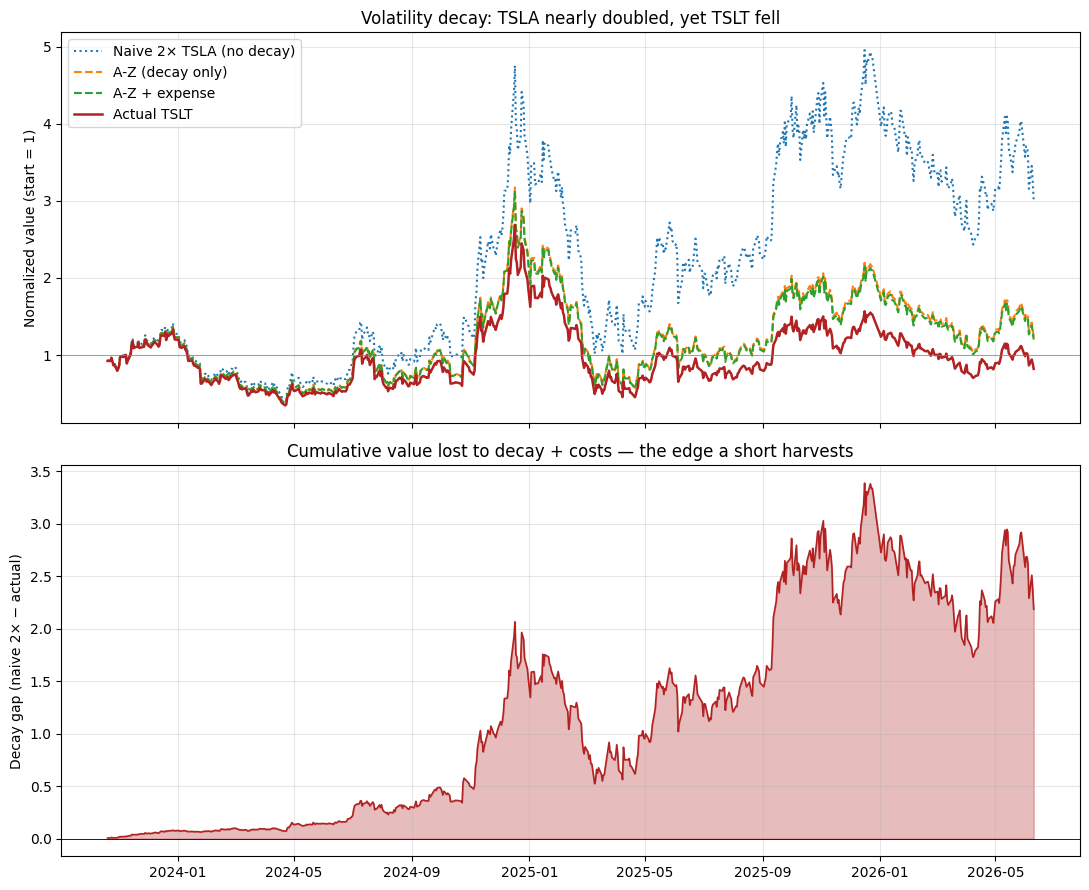

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

# Top: the four paths
ax[0].plot(comparison.index, comparison["naive_2x"],        ls=":",  label="Naive 2× TSLA (no decay)")
ax[0].plot(comparison.index, comparison["AZ_frictionless"], ls="--", label="A-Z (decay only)")
ax[0].plot(comparison.index, comparison["AZ_net_expense"],  ls="--", label="A-Z + expense")
ax[0].plot(comparison.index, comparison["actual_TSLT"], color="firebrick", lw=1.8, label="Actual TSLT")
ax[0].axhline(1.0, color="grey", lw=0.5)
ax[0].set_ylabel("Normalized value (start = 1)")
ax[0].set_title("Volatility decay: TSLA nearly doubled, yet TSLT fell")
ax[0].legend(); ax[0].grid(alpha=0.3)

# Bottom: the decay gap itself
gap = comparison["naive_2x"] - comparison["actual_TSLT"]
ax[1].fill_between(comparison.index, 0, gap, color="firebrick", alpha=0.3)
ax[1].plot(comparison.index, gap, color="firebrick", lw=1.2)
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_ylabel("Decay gap (naive 2× − actual)")
ax[1].set_title("Cumulative value lost to decay + costs — the edge a short harvests")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Strategy 1: Double-Short Strategy (Simultaneous Short of Long and Short LETF)

In [13]:
# Add TSLZ (the -2x inverse) to the existing two-ticker pull
INV = "TSLZ"

raw3 = yf.download([LETF, UNDER, INV], start=START, end=END, auto_adjust=True, progress=False)
px3 = raw3["Close"][[LETF, UNDER, INV]].dropna()   # select by name — avoid column-order trap

print(f"{len(px3)} aligned trading days: {px3.index.min().date()} -> {px3.index.max().date()}")
print("\nFirst rows:")
print(px3.head())

# Sanity check: TSLZ daily beta on TSLA should be about -2.0
ret3 = px3.pct_change().dropna()
inv_beta = np.polyfit(ret3[UNDER], ret3[INV], 1)[0]
print(f"\nEmpirical daily beta of {INV} on {UNDER}: {inv_beta:.3f}  (target = -2.0)")

662 aligned trading days: 2023-10-19 -> 2026-06-10

First rows:
Ticker           TSLT        TSLA        TSLZ
Date                                         
2023-10-19  20.455999  220.110001  612.686768
2023-10-20  18.892000  211.990005  658.062622
2023-10-23  18.860001  212.080002  658.321289
2023-10-24  19.590000  216.520004  628.984802
2023-10-25  18.889000  212.419998  652.785095

Empirical daily beta of TSLZ on TSLA: -1.991  (target = -2.0)


In [14]:
# --- Strategy 1: Double-Short (short TSLT + short TSLZ, equal dollar weights) ---
# Short $1 of each leg at inception. A short position's daily P&L = -1 * (asset return).
# Equity evolves as we accrue the P&L from both shorts.

w = 0.5   # equal dollar weight per leg (0.5 + 0.5 = $1 gross short capital deployed)

# Daily P&L per $1 short in each leg = -return
pnl_tslt = -ret3[LETF]
pnl_tslz = -ret3[INV]

# Combined daily portfolio return (before any borrow cost), equal-weighted
port_ret_gross = w * pnl_tslt + w * pnl_tslz

# Cumulative equity, starting at 1.0
equity_gross = (1 + port_ret_gross).cumprod()

print("Double-Short (gross, no borrow cost):")
print(f"  Total return:        {(equity_gross.iloc[-1] - 1)*100:.2f}%")
print(f"  Annualized return:   {((equity_gross.iloc[-1])**(252/len(equity_gross)) - 1)*100:.2f}%")
print(f"  Annualized vol:      {port_ret_gross.std()*np.sqrt(252)*100:.2f}%")
print(f"  Min equity (trough): {equity_gross.min():.3f}")
print(f"\nLast 5 days of equity:")
print(equity_gross.tail())

Double-Short (gross, no borrow cost):
  Total return:        17.75%
  Annualized return:   6.43%
  Annualized vol:      2.86%
  Min equity (trough): 0.997

Last 5 days of equity:
Date
2026-06-04    1.177516
2026-06-05    1.176967
2026-06-08    1.177964
2026-06-09    1.177333
2026-06-10    1.177534
dtype: float64


Static Double-Short (no rebalance, no borrow cost):
  Total return:        57.89%
  Annualized vol:      48.05%
  Min equity (trough): 0.625
  Max equity (peak):   1.708


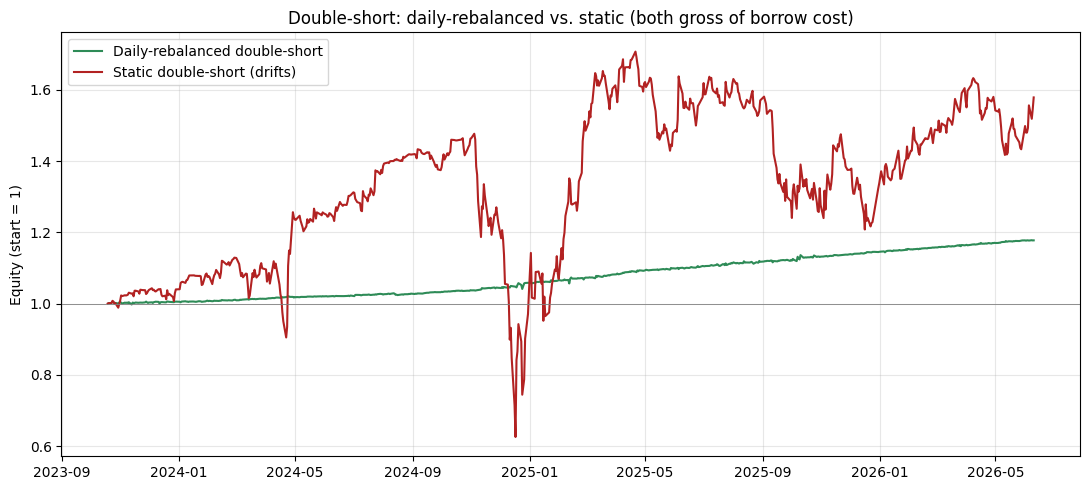

In [15]:
# --- Static double-short: short $1 of each leg on day 1, NEVER rebalance ---
# A $1 short grows/shrinks with the asset. Equity = cash from the two short proceeds
# minus the cost to buy them back at current prices.
# Value of a $1 short = 1 - (P_t/P_0 - 1) = 2 - P_t/P_0  (per $1 initial notional)

tslt_growth = px3[LETF] / px3[LETF].iloc[0]   # normalized price path of each leg
tslz_growth = px3[INV]  / px3[INV].iloc[0]

# Each leg starts at $0.50 short. Short-leg equity = initial - (growth-1)*initial
short_tslt_val = 0.5 * (1 - (tslt_growth - 1))   # = 0.5*(2 - growth)
short_tslz_val = 0.5 * (1 - (tslz_growth - 1))

equity_static = short_tslt_val + short_tslz_val   # total equity, starts at 1.0

print("Static Double-Short (no rebalance, no borrow cost):")
print(f"  Total return:        {(equity_static.iloc[-1] - 1)*100:.2f}%")
print(f"  Annualized vol:      {equity_static.pct_change().std()*np.sqrt(252)*100:.2f}%")
print(f"  Min equity (trough): {equity_static.min():.3f}")
print(f"  Max equity (peak):   {equity_static.max():.3f}")

# Compare the two versions on one plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(equity_gross.index, equity_gross, label="Daily-rebalanced double-short", color="seagreen")
ax.plot(equity_static.index, equity_static, label="Static double-short (drifts)", color="firebrick")
ax.axhline(1.0, color="grey", lw=0.6)
ax.set_title("Double-short: daily-rebalanced vs. static (both gross of borrow cost)")
ax.set_ylabel("Equity (start = 1)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Borrow assumption: TSLT 8% / TSLZ 8% annual

Rebalanced:  gross  17.75%   net  -4.53%
Static:      gross  57.89%   net  29.92%

Rebalanced gross annualized return: 6.43%
--> Breakeven combined borrow ~6.43%/yr (3.21% per leg)


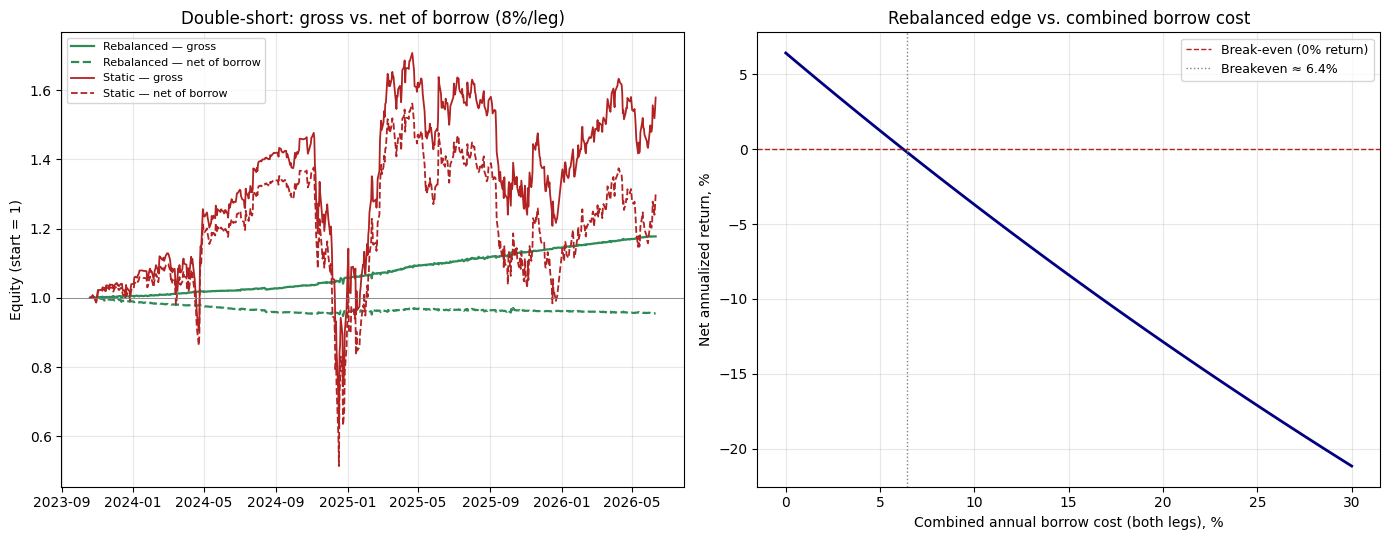

In [16]:
# --- Add borrow cost to the double-short (both legs) + visualization ---
borrow_tslt = 0.08   # annual borrow fee on TSLT short  (PLACEHOLDER)
borrow_tslz = 0.08   # annual borrow fee on TSLZ short  (PLACEHOLDER)

daily_b_tslt = borrow_tslt / 252
daily_b_tslz = borrow_tslz / 252

# Rebalanced: borrow on constant 0.5 per leg
borrow_drag_rebal = w * daily_b_tslt + w * daily_b_tslz
port_ret_net = port_ret_gross - borrow_drag_rebal
equity_rebal_net = (1 + port_ret_net).cumprod()

# Static: borrow on the drifting dollar value of each leg
borrow_drag_static = short_tslt_val.shift(1) * daily_b_tslt + short_tslz_val.shift(1) * daily_b_tslz
equity_static_net = (short_tslt_val + short_tslz_val) - borrow_drag_static.cumsum()

print(f"Borrow assumption: TSLT {borrow_tslt*100:.0f}% / TSLZ {borrow_tslz*100:.0f}% annual\n")
print("Rebalanced:  gross {:6.2f}%   net {:6.2f}%".format(
    (equity_gross.iloc[-1]-1)*100, (equity_rebal_net.iloc[-1]-1)*100))
print("Static:      gross {:6.2f}%   net {:6.2f}%".format(
    (equity_static.iloc[-1]-1)*100, (equity_static_net.iloc[-1]-1)*100))

gross_ann = (equity_gross.iloc[-1])**(252/len(equity_gross)) - 1
print(f"\nRebalanced gross annualized return: {gross_ann*100:.2f}%")
print(f"--> Breakeven combined borrow ~{gross_ann*100:.2f}%/yr ({gross_ann*100/2:.2f}% per leg)")

# ---------------- Visualization ----------------
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: equity curves, gross vs net
ax[0].plot(equity_gross.index,      equity_gross,      color="seagreen", lw=1.6, label="Rebalanced — gross")
ax[0].plot(equity_rebal_net.index,  equity_rebal_net,  color="seagreen", lw=1.6, ls="--", label="Rebalanced — net of borrow")
ax[0].plot(equity_static.index,     equity_static,     color="firebrick", lw=1.3, label="Static — gross")
ax[0].plot(equity_static_net.index, equity_static_net, color="firebrick", lw=1.3, ls="--", label="Static — net of borrow")
ax[0].axhline(1.0, color="grey", lw=0.6)
ax[0].set_title(f"Double-short: gross vs. net of borrow ({borrow_tslt*100:.0f}%/leg)")
ax[0].set_ylabel("Equity (start = 1)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

# Panel 2: breakeven sweep — rebalanced net return vs combined borrow rate
borrow_grid = np.linspace(0, 0.30, 61)          # 0% to 30% combined annual borrow
net_ann = []
for b in borrow_grid:
    r = port_ret_gross - b/252                   # b is COMBINED borrow on 1.0 notional
    eq = (1 + r).cumprod()
    net_ann.append((eq.iloc[-1])**(252/len(eq)) - 1)
net_ann = np.array(net_ann)

ax[1].plot(borrow_grid*100, net_ann*100, color="navy", lw=2)
ax[1].axhline(0, color="firebrick", lw=1, ls="--", label="Break-even (0% return)")
ax[1].axvline(gross_ann*100, color="grey", lw=1, ls=":", label=f"Breakeven ≈ {gross_ann*100:.1f}%")
ax[1].set_title("Rebalanced edge vs. combined borrow cost")
ax[1].set_xlabel("Combined annual borrow cost (both legs), %")
ax[1].set_ylabel("Net annualized return, %")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# --- Reusable risk-metrics function (use for all strategies) ---
def risk_metrics(equity, rf=0.0, periods=252):
    """Compute standard risk metrics from an equity curve (Series, start≈1)."""
    equity = equity.dropna()
    rets = equity.pct_change().dropna()
    n = len(rets)

    total_ret = equity.iloc[-1] / equity.iloc[0] - 1
    ann_ret   = (equity.iloc[-1] / equity.iloc[0])**(periods/n) - 1
    ann_vol   = rets.std() * np.sqrt(periods)
    sharpe    = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan

    # Max drawdown (peak-to-trough on the equity curve)
    running_max = equity.cummax()
    drawdown    = equity / running_max - 1
    mdd         = drawdown.min()

    calmar = ann_ret / abs(mdd) if mdd < 0 else np.nan

    # Downside deviation -> Sortino
    downside = rets[rets < 0]
    dd_dev   = downside.std() * np.sqrt(periods)
    sortino  = (ann_ret - rf) / dd_dev if dd_dev > 0 else np.nan

    return {
        "Total Return %": round(total_ret*100, 2),
        "Ann. Return %":  round(ann_ret*100, 2),
        "Ann. Vol %":     round(ann_vol*100, 2),
        "Sharpe":         round(sharpe, 3),
        "Sortino":        round(sortino, 3),
        "Max Drawdown %": round(mdd*100, 2),
        "Calmar":         round(calmar, 3),
    }

# --- Strategy 1 metrics: all four variants ---
results_s1 = {
    "Rebalanced (gross)": risk_metrics(equity_gross),
    "Rebalanced (net 4%/leg)": risk_metrics(equity_rebal_net),
    "Static (gross)": risk_metrics(equity_static),
    "Static (net 4%/leg)": risk_metrics(equity_static_net),
}

In [18]:
metrics_s1 = pd.DataFrame(results_s1).T
print("STRATEGY 1 — Double-Short risk metrics\n")
print(metrics_s1.to_string())

STRATEGY 1 — Double-Short risk metrics

                         Total Return %  Ann. Return %  Ann. Vol %  Sharpe  Sortino  Max Drawdown %  Calmar
Rebalanced (gross)                17.61           6.39        2.86   2.231    3.234           -1.54   4.156
Rebalanced (net 4%/leg)           -4.62          -1.79        2.86  -0.625   -0.936           -5.62  -0.319
Static (gross)                    57.89          19.02       48.05   0.396    0.562          -57.65   0.330
Static (net 4%/leg)               29.80          10.47       55.13   0.190    0.274          -62.66   0.167


In [19]:
# --- Master metrics table (accumulates across all strategies) ---
# Seed it with Strategy 1's four variants.

master_metrics = {}   # run this ONCE; re-running resets the table

def add_to_master(name, equity, rf=0.0):
    """Compute metrics for an equity curve and add as a labeled row to the master table."""
    master_metrics[name] = risk_metrics(equity, rf=rf)
    return master_metrics[name]

# --- Strategy 1 rows ---
add_to_master("S1: Rebal (gross)",       equity_gross)
add_to_master("S1: Rebal (net 4%/leg)",  equity_rebal_net)
add_to_master("S1: Static (gross)",      equity_static)
add_to_master("S1: Static (net 4%/leg)", equity_static_net)

def show_master():
    df = pd.DataFrame(master_metrics).T
    return df

show_master()

,Total Return %,Ann. Return %,Ann. Vol %,Sharpe,Sortino,Max Drawdown %,Calmar
S1: Rebal (gross),17.61,6.39,2.86,2.231,3.234,-1.54,4.156
S1: Rebal (net 4%/leg),-4.62,-1.79,2.86,-0.625,-0.936,-5.62,-0.319
S1: Static (gross),57.89,19.02,48.05,0.396,0.562,-57.65,0.330
S1: Static (net 4%/leg),29.80,10.47,55.13,0.190,0.274,-62.66,0.167


## Strategy 2: Delta-Adjusted Arbitrage (Long Underlying Asset + Short LETF)

Option A (net -1x)
  Total return:       -64.35%
  Annualized vol:      58.43%
  Min equity:        0.279
  Max equity:        1.513

Option B (delta-neutral)
  Total return:        23.59%
  Annualized vol:       1.66%
  Min equity:        1.001
  Max equity:        1.237



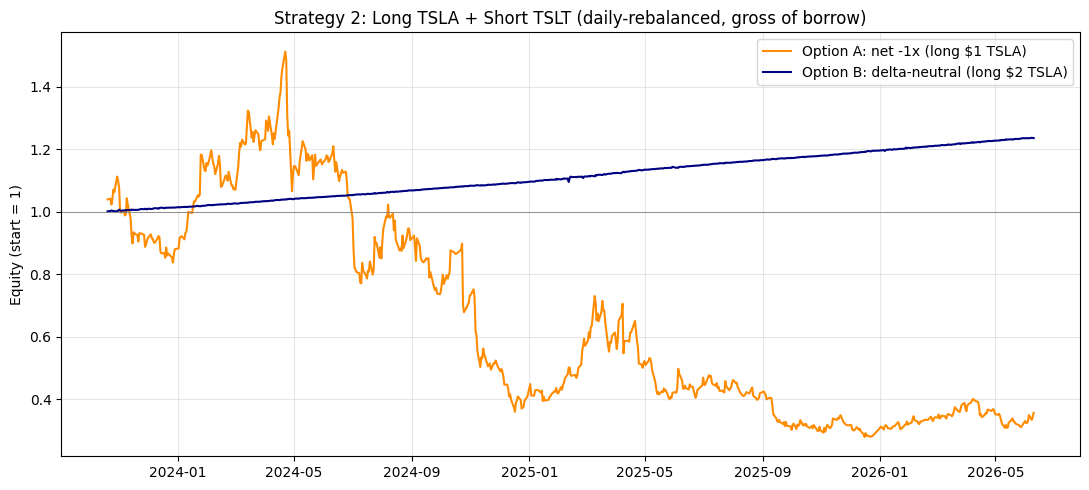

In [21]:
# --- Strategy 2: Long TSLA + Short TSLT (both sizings) ---
# Short leg: -1 unit of TSLT  -> -2x TSLA exposure
# Option A (net-short 1x):   long 1 unit TSLA  -> net -1x
# Option B (delta-neutral):  long 2 units TSLA -> net  0x at inception
# Daily-rebalanced: weights reset each day (consistent with S1 rebalanced version).

r_tslt = ret3[LETF]    # TSLT daily returns
r_tsla = ret3[UNDER]   # TSLA daily returns

# Daily P&L per $1 of exposure: long leg = +return, short leg = -return
# Option A: +1*r_tsla  - 1*r_tslt   (capital base = $1 long + $1 short collateral)
# Option B: +2*r_tsla  - 1*r_tslt

# We express each as a return on capital deployed. Use long-notional as the equity base.
# Option A: $1 long TSLA, $1 short TSLT  -> base $1 (the long position is the capital)
retA = r_tsla - r_tslt
# Option B: $2 long TSLA, $1 short TSLT  -> base $2 long; normalize P&L by the $2 base
retB = (2*r_tsla - r_tslt) / 2.0

equity_s2A = (1 + retA).cumprod()
equity_s2B = (1 + retB).cumprod()

for name, eq, ret_ in [("Option A (net -1x)", equity_s2A, retA),
                       ("Option B (delta-neutral)", equity_s2B, retB)]:
    print(f"{name}")
    print(f"  Total return:      {(eq.iloc[-1]-1)*100:7.2f}%")
    print(f"  Annualized vol:    {ret_.std()*np.sqrt(252)*100:7.2f}%")
    print(f"  Min equity:        {eq.min():.3f}")
    print(f"  Max equity:        {eq.max():.3f}\n")

# Plot both against the equity=1 line
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(equity_s2A.index, equity_s2A, color="darkorange", lw=1.5, label="Option A: net -1x (long $1 TSLA)")
ax.plot(equity_s2B.index, equity_s2B, color="navy",       lw=1.5, label="Option B: delta-neutral (long $2 TSLA)")
ax.axhline(1.0, color="grey", lw=0.6)
ax.set_title("Strategy 2: Long TSLA + Short TSLT (daily-rebalanced, gross of borrow)")
ax.set_ylabel("Equity (start = 1)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Option A static (net -1x)
  Total return:      45.67%
  Annualized vol:    22.84%
  Min equity:      0.746
  Max equity:      1.457

Option B static (delta-neutral d1)
  Total return:      54.90%
  Annualized vol:    14.29%
  Min equity:      0.981
  Max equity:      1.634



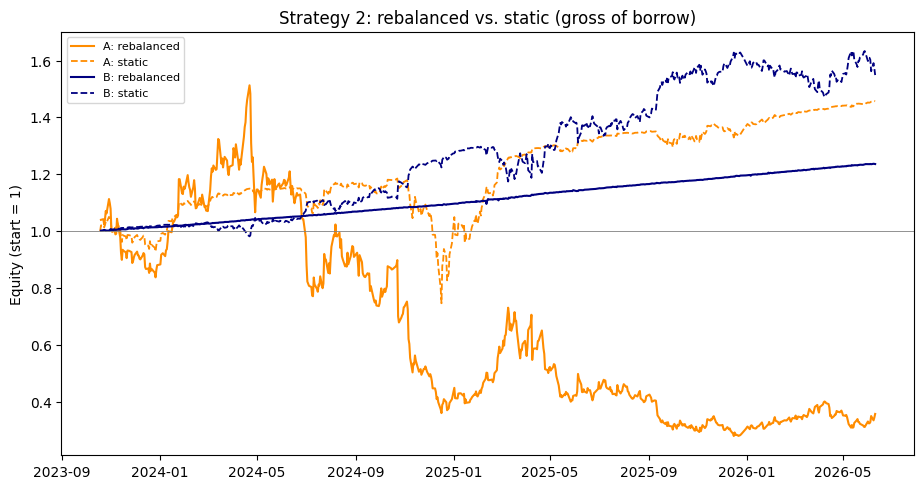

In [22]:
# --- Strategy 2 STATIC: set positions day 1, never rebalance ---
# Normalized price paths (start = 1)
tsla_g = px3[UNDER] / px3[UNDER].iloc[0]
tslt_g = px3[LETF]  / px3[LETF].iloc[0]

# Long leg value evolves with TSLA; short leg value = initial - (growth - 1)*initial = (2 - growth)*initial
# Equity = long position value + short position value, on the capital base, normalized to start at 1.

# Option A static: long $1 TSLA, short $1 TSLT, base = $1
#   long contributes tsla_g ; short $1 contributes (2 - tslt_g) ; start value = 1 + 1 = 2 -> normalize
valA_static = (tsla_g + (2 - tslt_g)) / 2.0      # starts at (1+1)/2 = 1.0

# Option B static: long $2 TSLA, short $1 TSLT, base = $2 long
#   long $2 contributes 2*tsla_g ; short $1 contributes (2 - tslt_g) ; start = 2 + 1 = 3 -> normalize to 1
valB_static = (2*tsla_g + (2 - tslt_g)) / 3.0    # starts at (2+1)/3 = 1.0

for name, eq in [("Option A static (net -1x)", valA_static),
                 ("Option B static (delta-neutral d1)", valB_static)]:
    rets = eq.pct_change().dropna()
    print(f"{name}")
    print(f"  Total return:    {(eq.iloc[-1]-1)*100:7.2f}%")
    print(f"  Annualized vol:  {rets.std()*np.sqrt(252)*100:7.2f}%")
    print(f"  Min equity:      {eq.min():.3f}")
    print(f"  Max equity:      {eq.max():.3f}\n")

# Plot: rebalanced vs static, both options
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(equity_s2A.index, equity_s2A, color="darkorange", lw=1.5, label="A: rebalanced")
ax.plot(valA_static.index, valA_static, color="darkorange", lw=1.3, ls="--", label="A: static")
ax.plot(equity_s2B.index, equity_s2B, color="navy", lw=1.5, label="B: rebalanced")
ax.plot(valB_static.index, valB_static, color="navy", lw=1.3, ls="--", label="B: static")
ax.axhline(1.0, color="grey", lw=0.6)
ax.set_title("Strategy 2: rebalanced vs. static (gross of borrow)")
ax.set_ylabel("Equity (start = 1)")
ax.legend(fontsize=8);

In [23]:
# ============================================================
# UNIFIED CAPITAL CONVENTION
# Convention: return on GROSS capital deployed
#   C = sum of |signed dollar notional| across legs (fully collateralized)
#   rf = 0 in P&L accounting; GROSS of borrow (borrow added uniformly later)
# ============================================================

def build_strategy(positions, returns_df, prices_df):
    """
    positions : dict {ticker: signed dollar notional}, e.g. {'TSLT':-1,'TSLZ':-1}
    Returns (equity_rebalanced, equity_static), each a Series starting at 1.0.
    Handles LINEAR legs only (long/short shares/ETFs) — not options.
    """
    C = sum(abs(v) for v in positions.values())

    # Rebalanced: target dollar exposures reset to target each day
    daily_pnl_rebal = sum(positions[t] * returns_df[t] for t in positions)
    equity_rebal = (1 + daily_pnl_rebal / C).cumprod()

    # Static: positions set on day 1, drift thereafter
    growth = {t: prices_df[t] / prices_df[t].iloc[0] for t in positions}
    pnl_static = sum(positions[t] * (growth[t] - 1) for t in positions)
    equity_static = (C + pnl_static) / C

    return equity_rebal, equity_static


# Define every (linear) strategy as signed dollar positions
strategies = {
    "S1 Double-Short":  {"TSLT": -1, "TSLZ": -1},   # C = 2,  net 0x day1
    "S2A Long1/Short1": {"TSLA":  1, "TSLT": -1},   # C = 2,  net -1x
    "S2B Long2/Short1": {"TSLA":  2, "TSLT": -1},   # C = 3,  net 0x day1
}

# Build all equity curves on the unified basis
curves = {}
for name, pos in strategies.items():
    eq_r, eq_s = build_strategy(pos, ret3, px3)
    curves[f"{name} [rebal]"]  = eq_r
    curves[f"{name} [static]"] = eq_s

# Rebuild master table from scratch, consistently
master_metrics = {label: risk_metrics(eq) for label, eq in curves.items()}
master_df = pd.DataFrame(master_metrics).T

print("Capital convention: return on gross deployed capital (Σ|notionals|), rf=0, gross of borrow\n")
master_df

Capital convention: return on gross deployed capital (Σ|notionals|), rf=0, gross of borrow



,Total Return %,Ann. Return %,Ann. Vol %,Sharpe,Sortino,Max Drawdown %,Calmar
S1 Double-Short [rebal],17.61,6.39,2.86,2.231,3.234,-1.54,4.156
S1 Double-Short [static],57.89,19.02,48.05,0.396,0.562,-57.65,0.330
S2A Long1/Short1 [rebal],-34.24,-14.79,29.21,-0.506,-0.664,-52.83,-0.280
S2A Long1/Short1 [static],45.67,15.42,22.84,0.675,0.808,-37.05,0.416
S2B Long2/Short1 [rebal],15.07,5.51,1.10,4.986,6.411,-0.69,8.010
S2B Long2/Short1 [static],54.90,18.16,14.29,1.271,1.942,-9.73,1.867


NET OF BORROW (TSLT/TSLZ @ 8%, TSLA long @ 0%)

                           Total Return %  Ann. Return %  Ann. Vol %  Sharpe  Sortino  Max Drawdown %  Calmar
S1 Double-Short [rebal]             -4.62          -1.79        2.86  -0.625   -0.936           -5.62  -0.319
S1 Double-Short [static]            43.91          14.89       52.31   0.285    0.407          -60.93   0.244
S2A Long1/Short1 [rebal]           -40.79         -18.13       29.21  -0.621   -0.814          -55.84  -0.325
S2A Long1/Short1 [static]           35.56          12.30       23.77   0.517    0.624          -38.72   0.318
S2B Long2/Short1 [rebal]             7.31           2.73        1.10   2.472    3.320           -0.72   3.797
S2B Long2/Short1 [static]           48.16          16.17       14.71   1.099    1.678          -10.59   1.527


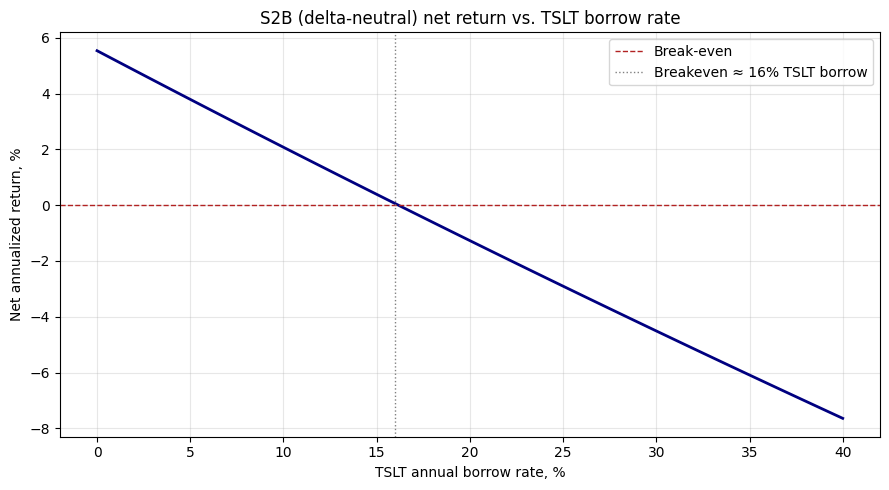


S2B breakeven TSLT borrow rate ≈ 16.0%


In [24]:
# ============================================================
# UNIFORM BORROW LAYER — short legs only, applied to all strategies
# ============================================================

# Per-ticker annual borrow rate. PLACEHOLDERS — replace with Bloomberg rates.
# Longs cost nothing to hold; only shorts pay borrow.
borrow_rates = {
    "TSLT": 0.08,   # PLACEHOLDER
    "TSLZ": 0.08,   # PLACEHOLDER
    "TSLA": 0.00,   # you own the stock; no borrow (it's the long leg here)
}

def build_strategy_net(positions, returns_df, prices_df, brates):
    """Same as build_strategy but subtracts borrow on short legs. Returns (rebal, static)."""
    C = sum(abs(v) for v in positions.values())

    # --- Rebalanced: short notional reset to target each day -> constant daily borrow ---
    daily_pnl_rebal = sum(positions[t] * returns_df[t] for t in positions)
    daily_borrow_rebal = sum(abs(positions[t]) * brates.get(t, 0.0) / 252
                             for t in positions if positions[t] < 0)
    equity_rebal = (1 + (daily_pnl_rebal - daily_borrow_rebal) / C).cumprod()

    # --- Static: borrow accrues on the drifting market value of each short leg ---
    growth = {t: prices_df[t] / prices_df[t].iloc[0] for t in positions}
    pnl_static = sum(positions[t] * (growth[t] - 1) for t in positions)
    # daily borrow $ on each short leg = |pos| * growth_{t-1} * rate/252
    borrow_dollars = sum(abs(positions[t]) * growth[t].shift(1).fillna(1.0) * brates.get(t, 0.0) / 252
                         for t in positions if positions[t] < 0)
    equity_static = (C + pnl_static - borrow_dollars.cumsum()) / C

    return equity_rebal, equity_static

# Rebuild all curves net of borrow
curves_net = {}
for name, pos in strategies.items():
    eq_r, eq_s = build_strategy_net(pos, ret3, px3, borrow_rates)
    curves_net[f"{name} [rebal]"]  = eq_r
    curves_net[f"{name} [static]"] = eq_s

master_net = pd.DataFrame({label: risk_metrics(eq) for label, eq in curves_net.items()}).T
print(f"NET OF BORROW (TSLT/TSLZ @ {borrow_rates['TSLT']*100:.0f}%, TSLA long @ 0%)\n")
print(master_net.to_string())

# ---------------- Breakeven borrow sweep for S2B rebalanced ----------------
posB = strategies["S2B Long2/Short1"]
C_B  = sum(abs(v) for v in posB.values())          # = 3
pnlB = sum(posB[t] * ret3[t] for t in posB)         # gross daily P&L
short_notional_B = sum(abs(posB[t]) for t in posB if posB[t] < 0)   # = 1 (only TSLT)

borrow_grid = np.linspace(0, 0.40, 81)
s2b_net_ann = []
for b in borrow_grid:
    drag = short_notional_B * b / 252
    eq = (1 + (pnlB - drag) / C_B).cumprod()
    s2b_net_ann.append((eq.iloc[-1])**(252/len(eq)) - 1)
s2b_net_ann = np.array(s2b_net_ann)

# breakeven borrow rate (where net annualized return crosses 0)
be_idx = np.argmin(np.abs(s2b_net_ann))
be_rate = borrow_grid[be_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(borrow_grid*100, s2b_net_ann*100, color="navy", lw=2)
ax.axhline(0, color="firebrick", ls="--", lw=1, label="Break-even")
ax.axvline(be_rate*100, color="grey", ls=":", lw=1, label=f"Breakeven ≈ {be_rate*100:.0f}% TSLT borrow")
ax.set_title("S2B (delta-neutral) net return vs. TSLT borrow rate")
ax.set_xlabel("TSLT annual borrow rate, %")
ax.set_ylabel("Net annualized return, %")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nS2B breakeven TSLT borrow rate ≈ {be_rate*100:.1f}%")

## Strategy 3: Convexity Protection (Short Long LETFs + Long Call Option)

### Short TSLT + Long TSLA Call

In [27]:
# ============================================================
# STRATEGY 3 — engine part 1: option selection + rolling schedule
# Short $1 TSLT + long beta-scaled TSLA call (convexity protection)
# ============================================================

opt = pd.read_parquet("TSLA_calls_close.parquet")
# Restrict to the frozen window and tidy
opt = opt[(opt["date"] >= START) & (opt["date"] < END)][["expiry","strike","date","px_last","px_volume"]].copy()

# Build a fast lookup: for a given date, what contracts trade, and at what price
opt = opt.sort_values(["date","expiry","strike"]).reset_index(drop=True)

# TSLA spot from your frozen price data (px3 has TSLA), aligned to option dates
spot = px3[UNDER]

def build_hedge_schedule(target_dte, moneyness, roll_buffer=20, min_volume=1):
    """
    Returns a DataFrame indexed by trading date with the held call's
    expiry, strike, and px_last — rolling to a new contract when the
    current one nears expiry.
      target_dte : desired days to expiry at (re)entry, e.g. 60
      moneyness  : 0.0 = ATM, 0.10 = 10% OTM, 0.20 = 20% OTM
      roll_buffer: roll when held contract has <= this many days left
    """
    dates = spot.index
    rows = []
    held_expiry = None
    held_strike = None

    for d in dates:
        S = spot.loc[d]
        day_opts = opt[opt["date"] == d]
        if day_opts.empty:
            rows.append((d, np.nan, np.nan, np.nan, np.nan, False)); continue

        # Decide whether we need to (re)select a contract
        need_new = False
        if held_expiry is None:
            need_new = True
        else:
            dte_left = (held_expiry - d).days
            if dte_left <= roll_buffer:
                need_new = True

        if need_new:
            # pick expiry closest to target_dte (and at least roll_buffer away)
            exp_pool = day_opts[(day_opts["expiry"] - d).dt.days > roll_buffer]["expiry"].unique()
            if len(exp_pool) == 0:
                rows.append((d, np.nan, np.nan, np.nan, np.nan, False)); continue
            target_date = d + pd.Timedelta(days=target_dte)
            chosen_exp = min(exp_pool, key=lambda e: abs((pd.Timestamp(e) - target_date).days))
            # pick strike closest to target moneyness
            target_strike = S * (1 + moneyness)
            exp_strikes = day_opts[day_opts["expiry"] == chosen_exp]
            chosen_strike = exp_strikes.iloc[(exp_strikes["strike"] - target_strike).abs().argsort().iloc[0]]["strike"]
            held_expiry, held_strike = pd.Timestamp(chosen_exp), chosen_strike
            rolled = True
        else:
            rolled = False

        # price of the held contract today
        match = day_opts[(day_opts["expiry"] == held_expiry) & (day_opts["strike"] == held_strike)]
        price = match["px_last"].iloc[0] if not match.empty else np.nan
        rows.append((d, held_expiry, held_strike, price, S, rolled))

    sched = pd.DataFrame(rows, columns=["date","expiry","strike","call_px","spot","rolled"]).set_index("date")
    sched["dte"] = (sched["expiry"] - sched.index).dt.days
    sched["moneyness_actual"] = sched["strike"]/sched["spot"] - 1
    return sched

# Build the 60-day, ATM schedule as the first test
sched_60_atm = build_hedge_schedule(target_dte=60, moneyness=0.0)

print("60-day ATM hedge schedule — summary")
print(f"  Trading days:        {len(sched_60_atm)}")
print(f"  Number of rolls:     {sched_60_atm['rolled'].sum()}")
print(f"  Days missing a price: {sched_60_atm['call_px'].isna().sum()}")
print(f"  Avg DTE held:        {sched_60_atm['dte'].mean():.1f}")
print(f"  Avg actual moneyness: {sched_60_atm['moneyness_actual'].mean()*100:.2f}%")
print("\nFirst rows around the first roll:")
print(sched_60_atm.head(3).to_string())
print("\nRoll dates (where contract changes):")
print(sched_60_atm[sched_60_atm['rolled']][['expiry','strike','call_px','spot','dte','moneyness_actual']].to_string())

60-day ATM hedge schedule — summary
  Trading days:        662
  Number of rolls:     29
  Days missing a price: 0
  Avg DTE held:        37.7
  Avg actual moneyness: 2.23%

First rows around the first roll:
               expiry  strike  call_px        spot  rolled  dte  moneyness_actual
date                                                                             
2023-10-19 2023-12-15   220.0    17.95  220.110001    True   57         -0.000500
2023-10-20 2023-12-15   220.0    13.65  211.990005   False   56          0.037785
2023-10-23 2023-12-15   220.0    13.10  212.080002   False   53          0.037344

Roll dates (where contract changes):
               expiry  strike  call_px        spot  dte  moneyness_actual
date                                                                     
2023-10-19 2023-12-15  220.00    17.95  220.110001   57         -0.000500
2023-11-27 2024-01-19  236.67    16.52  236.080002   53          0.002499
2024-01-02 2024-03-15  250.00    21.35  248.4199

In [28]:
# ============================================================
# STRATEGY 3 — P&L with EXACT premium cash-flow accounting
# Short $1 TSLT + long TSLA calls on $2 TSLA notional (full 2x coverage)
# Equity = cash + market value of held call. Premiums explicitly paid/received.
# ============================================================

def run_strategy3(sched, borrow_tslt=0.0):
    dates = sched.index
    r_tslt = ret3[LETF].reindex(dates).fillna(0.0)

    cash         = 1.0      # $1 short-collateral capital base
    short_not    = 1.0      # constant $1 short TSLT (rebalanced daily)
    call_shares  = 0.0      # TSLA-equiv shares the held call references
    held_key     = None     # (expiry, strike) of the call currently held
    equity = pd.Series(index=dates, dtype=float)
    rows = []

    for d in dates:
        row = sched.loc[d]
        S, cpx = row["spot"], row["call_px"]
        key = (row["expiry"], row["strike"])

        # ---- 1. short TSLT daily P&L (cash) ----
        pnl_short = -short_not * r_tslt.loc[d]
        borrow    = short_not * borrow_tslt / 252
        cash += pnl_short - borrow

        # ---- 2. option roll: if the contract key changed, SELL old + BUY new ----
        prem_paid = prem_recd = 0.0
        if key != held_key:
            # sell the previously held call at TODAY's price of the OLD contract
            if held_key is not None:
                old_px = _price_of(sched, d, held_key)     # old contract's price today
                prem_recd = call_shares * old_px
                cash += prem_recd                           # proceeds back to cash
            # buy the new call: size to $2 TSLA notional, pay full premium
            call_shares = 2.0 / S
            prem_paid   = call_shares * cpx
            cash -= prem_paid                               # premium debited
            held_key = key

        # ---- 3. mark held call to market: equity = cash + call value ----
        call_value = call_shares * cpx
        equity.loc[d] = cash + call_value
        rows.append((d, pnl_short, borrow, prem_paid, prem_recd, call_value, cash, S, cpx))

    detail = pd.DataFrame(rows, columns=[
        "date","pnl_short","borrow","prem_paid","prem_recd","call_value","cash","spot","call_px"
    ]).set_index("date")
    return equity, detail


def _price_of(sched, d, key):
    """Look up the price of a specific (expiry,strike) contract on date d from the raw option table."""
    exp, strk = key
    m = opt[(opt["date"]==d) & (opt["expiry"]==exp) & (opt["strike"]==strk)]
    if not m.empty:
        return m["px_last"].iloc[0]
    # fallback: contract not quoted today -> use last known schedule price (rare)
    return sched.loc[d, "call_px"]


# --- run it on the 60-day ATM schedule, gross of borrow first ---
eq_s3_60atm, detail_60atm = run_strategy3(sched_60_atm, borrow_tslt=0.0)

print("Strategy 3 — 60-day ATM, full 2x call coverage (gross of borrow)\n")
print(f"  Total return:        {(eq_s3_60atm.iloc[-1]-1)*100:7.2f}%")
print(f"  Total premium paid:  {detail_60atm['prem_paid'].sum():7.3f}  (cumulative, on $1 capital)")
print(f"  Total premium recovered: {detail_60atm['prem_recd'].sum():7.3f}")
print(f"  Net premium drag:    {(detail_60atm['prem_paid'].sum()-detail_60atm['prem_recd'].sum()):7.3f}")
print(f"  Min equity (trough): {eq_s3_60atm.min():.3f}")
print(f"  Max equity (peak):   {eq_s3_60atm.max():.3f}")

# compare to the naked short (no call) on the same basis
dates = sched_60_atm.index
naked = (1 + (-ret3[LETF].reindex(dates).fillna(0.0))).cumprod()
print(f"\n  Naked short $1 TSLT total return: {(naked.iloc[-1]-1)*100:7.2f}%")

Strategy 3 — 60-day ATM, full 2x call coverage (gross of borrow)

  Total return:         -82.02%
  Total premium paid:    4.729  (cumulative, on $1 capital)
  Total premium recovered:   5.447
  Net premium drag:     -0.717
  Min equity (trough): 0.016
  Max equity (peak):   1.435

  Naked short $1 TSLT total return:  -96.95%


In [29]:
# Sanity check: does a STATIC short of $1 TSLT actually harvest decay?
dates = sched_60_atm.index
tslt_g = px3[LETF].reindex(dates) / px3[LETF].reindex(dates).iloc[0]   # normalized TSLT path

# Static short $1: equity = 1 + (1 - tslt_growth) = 2 - tslt_growth  (per $1 short notional)
static_short = 2 - tslt_g

print("Static short $1 TSLT (buy-and-hold the short):")
print(f"  Total return:        {(static_short.iloc[-1]-1)*100:7.2f}%")
print(f"  Min equity (trough): {static_short.min():.3f}")
print(f"  Max equity (peak):   {static_short.max():.3f}")
print(f"  TSLT start -> end:   {px3[LETF].reindex(dates).iloc[0]:.2f} -> {px3[LETF].reindex(dates).iloc[-1]:.2f}")

Static short $1 TSLT (buy-and-hold the short):
  Total return:          17.97%
  Min equity (trough): -0.688
  Max equity (peak):   1.653
  TSLT start -> end:   20.46 -> 16.78


STRATEGY 3 — static short $1 TSLT + full 2x ATM call coverage (60-day, gross)

  Hedged total return:     93.01%
  Hedged min (trough):   0.603   <-- the number that matters
  Hedged max (peak):     2.066
  Total premium paid:    4.729
  Total premium recd:    5.447
  Net premium drag:      -0.717

  Naked static short:    return 17.97%, trough -0.688


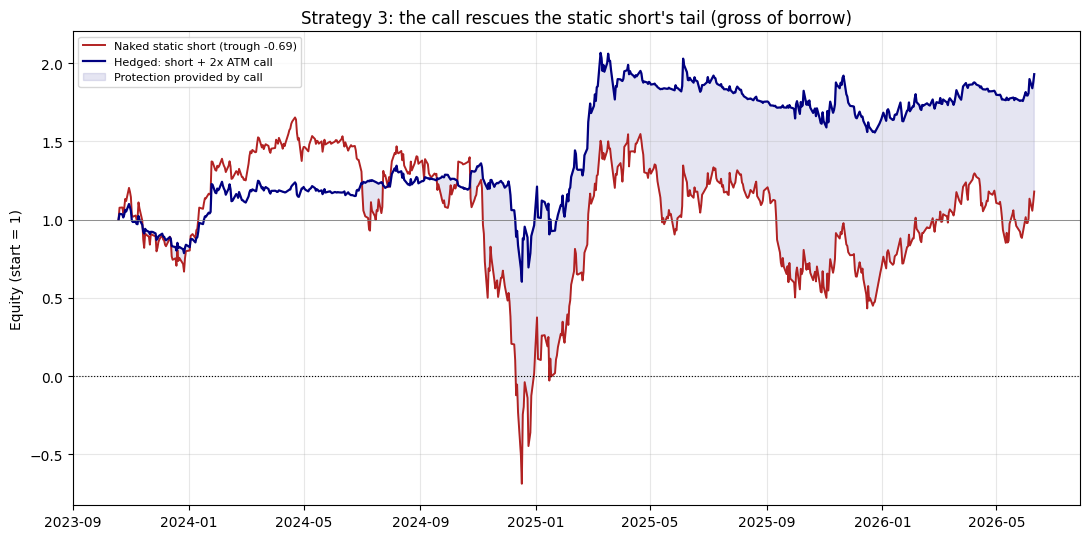

In [30]:
# ============================================================
# STRATEGY 3 (corrected) — STATIC short $1 TSLT + long beta-scaled TSLA calls
# Equity = 1.0 + cum_short_pnl + cum_call_pnl   (exact cash-flow accounting)
# ============================================================

def run_strategy3_static(sched, coverage=2.0, borrow_tslt=0.0):
    """
    Static short $1 TSLT (held, not rebalanced) + long TSLA calls on `coverage`
    dollars of TSLA notional (2.0 = full 2x coverage), rolled per `sched`.
    Returns (equity Series, detail DataFrame).
    """
    dates = sched.index
    tslt_g = (px3[LETF].reindex(dates) / px3[LETF].reindex(dates).iloc[0])   # normalized TSLT
    # cumulative short P&L for a static $1 short = -(growth - 1)
    cum_short_pnl = -(tslt_g - 1.0)

    cash_opt   = 0.0      # running cash from option buys/sells (starts 0)
    call_shares = 0.0
    held_key    = None
    equity = pd.Series(index=dates, dtype=float)
    rows = []

    # static short also pays borrow daily on its CURRENT (drifting) market value
    cum_borrow = 0.0

    for j, d in enumerate(dates):
        row = sched.loc[d]
        S, cpx = row["spot"], row["call_px"]
        key = (row["expiry"], row["strike"])

        prem_paid = prem_recd = 0.0
        if key != held_key:
            if held_key is not None:
                old_px = _price_of(sched, d, held_key)
                prem_recd = call_shares * old_px
                cash_opt += prem_recd                  # sell old at its price today
            call_shares = coverage / S                 # cover `coverage` $ of TSLA notional
            prem_paid = call_shares * cpx
            cash_opt -= prem_paid                      # buy new, pay full premium
            held_key = key

        call_value = call_shares * cpx                 # current mark of held call
        cum_call_pnl = cash_opt + call_value           # realized + unrealized, premium-exact

        # borrow on the static short's current market value ($1 * tslt_growth)
        cum_borrow += (tslt_g.iloc[j]) * borrow_tslt / 252

        equity.loc[d] = 1.0 + cum_short_pnl.iloc[j] + cum_call_pnl - cum_borrow
        rows.append((d, cum_short_pnl.iloc[j], cum_call_pnl, call_value, prem_paid, prem_recd, S, cpx))

    detail = pd.DataFrame(rows, columns=[
        "date","cum_short_pnl","cum_call_pnl","call_value","prem_paid","prem_recd","spot","call_px"
    ]).set_index("date")
    return equity, detail


# --- run on 60-day ATM, gross of borrow ---
eq_s3, det_s3 = run_strategy3_static(sched_60_atm, coverage=2.0, borrow_tslt=0.0)

# naked static short for comparison
dates = sched_60_atm.index
tslt_g = px3[LETF].reindex(dates) / px3[LETF].reindex(dates).iloc[0]
naked_static = 2 - tslt_g

print("STRATEGY 3 — static short $1 TSLT + full 2x ATM call coverage (60-day, gross)\n")
print(f"  Hedged total return:   {(eq_s3.iloc[-1]-1)*100:7.2f}%")
print(f"  Hedged min (trough):   {eq_s3.min():.3f}   <-- the number that matters")
print(f"  Hedged max (peak):     {eq_s3.max():.3f}")
print(f"  Total premium paid:    {det_s3['prem_paid'].sum():.3f}")
print(f"  Total premium recd:    {det_s3['prem_recd'].sum():.3f}")
print(f"  Net premium drag:      {det_s3['prem_paid'].sum() - det_s3['prem_recd'].sum():.3f}")
print()
print(f"  Naked static short:    return {(naked_static.iloc[-1]-1)*100:.2f}%, trough {naked_static.min():.3f}")

# Plot: naked vs hedged, with the rescue visible
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(naked_static.index, naked_static, color="firebrick", lw=1.4, label="Naked static short (trough -0.69)")
ax.plot(eq_s3.index, eq_s3, color="navy", lw=1.6, label="Hedged: short + 2x ATM call")
ax.axhline(1.0, color="grey", lw=0.6)
ax.axhline(0.0, color="black", lw=0.8, ls=":")
ax.fill_between(naked_static.index, naked_static, eq_s3, where=(eq_s3 > naked_static),
                color="navy", alpha=0.10, label="Protection provided by call")
ax.set_title("Strategy 3: the call rescues the static short's tail (gross of borrow)")
ax.set_ylabel("Equity (start = 1)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# STRATEGY 3 — moneyness × maturity sweep (gross of borrow)
# Grid: ATM/10%/20% OTM  ×  30/60/90/180-day target DTE
# Metrics: total return, trough (survivability), net premium drag
# ============================================================

moneyness_grid = [0.0, 0.10, 0.20]
maturity_grid  = [30, 60, 90, 180]

sweep_rows = []
sweep_curves = {}   # store equity curves for plotting

for dte in maturity_grid:
    for mny in moneyness_grid:
        sched = build_hedge_schedule(target_dte=dte, moneyness=mny)
        eq, det = run_strategy3_static(sched, coverage=2.0, borrow_tslt=0.0)
        label = f"{int(mny*100)}%OTM_{dte}d" if mny > 0 else f"ATM_{dte}d"
        sweep_curves[label] = eq
        sweep_rows.append({
            "DTE": dte,
            "Moneyness": "ATM" if mny == 0 else f"{int(mny*100)}% OTM",
            "Total Ret %": round((eq.iloc[-1]-1)*100, 1),
            "Trough":      round(eq.min(), 3),
            "Peak":        round(eq.max(), 3),
            "Prem Paid":   round(det["prem_paid"].sum(), 2),
            "Net Drag":    round(det["prem_paid"].sum() - det["prem_recd"].sum(), 3),
            "Rolls":       int(sched["rolled"].sum()),
        })

sweep = pd.DataFrame(sweep_rows)
print("STRATEGY 3 SWEEP — static short + 2x call coverage (gross of borrow)")
print("Naked static short reference: return 17.97%, trough -0.688\n")
print(sweep.to_string(index=False))

# Pivot tables for the two key dimensions
print("\n--- TROUGH (survivability; higher = safer) ---")
print(sweep.pivot(index="Moneyness", columns="DTE", values="Trough").to_string())
print("\n--- TOTAL RETURN % ---")
print(sweep.pivot(index="Moneyness", columns="DTE", values="Total Ret %").to_string())
print("\n--- NET PREMIUM DRAG (negative = calls profited) ---")
print(sweep.pivot(index="Moneyness", columns="DTE", values="Net Drag").to_string())

STRATEGY 3 SWEEP — static short + 2x call coverage (gross of borrow)
Naked static short reference: return 17.97%, trough -0.688

 DTE Moneyness  Total Ret %  Trough  Peak  Prem Paid  Net Drag  Rolls
  30       ATM         94.4   0.689 2.052       5.14    -0.731     33
  30   10% OTM         70.2   0.396 1.952       2.76    -0.507     33
  30   20% OTM         36.3   0.019 1.737       1.48    -0.175     33
  60       ATM         93.0   0.603 2.066       4.73    -0.717     29
  60   10% OTM         58.9   0.247 1.845       2.58    -0.394     29
  60   20% OTM         26.7  -0.089 1.641       1.42    -0.079     29
  90       ATM         85.2   0.753 2.075       3.29    -0.536     16
  90   10% OTM         69.6   0.547 1.995       2.04    -0.457     16
  90   20% OTM         56.8   0.358 1.901       1.28    -0.358     16
 180       ATM         97.9   0.851 2.359       2.11    -0.633      7
 180   10% OTM         92.3   0.817 2.236       1.69    -0.632      7
 180   20% OTM          NaN   0

In [32]:
# Diagnose the NaN in 180d / 20% OTM
sched_bad = build_hedge_schedule(target_dte=180, moneyness=0.20)
print("Last 5 rows of the schedule:")
print(sched_bad[["expiry","strike","call_px","spot","dte"]].tail())
print("\nAny NaN call prices?", sched_bad["call_px"].isna().sum())
print("Dates with NaN price:")
print(sched_bad[sched_bad["call_px"].isna()].index.tolist())

Last 5 rows of the schedule:
               expiry  strike  call_px        spot  dte
date                                                   
2026-06-04 2026-11-20   525.0    27.10  418.450012  169
2026-06-05 2026-11-20   525.0    19.75  391.000000  168
2026-06-08 2026-11-20   525.0    22.43  408.950012  165
2026-06-09 2026-11-20   525.0    20.65  396.679993  164
2026-06-10 2026-11-20   525.0      NaN  381.589996  163

Any NaN call prices? 2
Dates with NaN price:
[Timestamp('2024-09-04 00:00:00'), Timestamp('2026-06-10 00:00:00')]


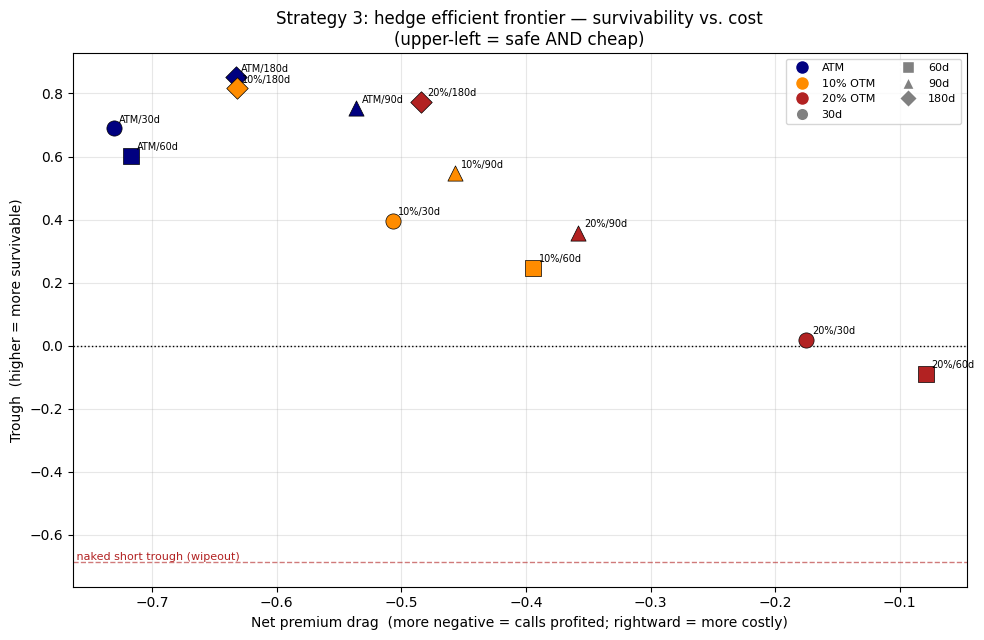

In [33]:
# --- Efficient frontier of the hedge: survivability vs. cost ---
fig, ax = plt.subplots(figsize=(10, 6.5))

colors = {"ATM": "navy", "10% OTM": "darkorange", "20% OTM": "firebrick"}
markers = {30: "o", 60: "s", 90: "^", 180: "D"}

for _, r in sweep.iterrows():
    ax.scatter(r["Net Drag"], r["Trough"],
               c=colors[r["Moneyness"]], marker=markers[r["DTE"]], s=120,
               edgecolor="black", linewidth=0.5, zorder=3)
    ax.annotate(f'{r["Moneyness"].replace(" OTM","")}/{r["DTE"]}d',
                (r["Net Drag"], r["Trough"]), fontsize=7,
                xytext=(4,4), textcoords="offset points")

# reference lines
ax.axhline(0, color="black", lw=1, ls=":")
ax.axhline(-0.688, color="firebrick", lw=1, ls="--", alpha=0.6)
ax.text(ax.get_xlim()[0], -0.688, " naked short trough (wipeout)", fontsize=8, color="firebrick", va="bottom")

ax.set_xlabel("Net premium drag  (more negative = calls profited; rightward = more costly)")
ax.set_ylabel("Trough  (higher = more survivable)")
ax.set_title("Strategy 3: hedge efficient frontier — survivability vs. cost\n(upper-left = safe AND cheap)")
ax.grid(alpha=0.3)

# legend
from matplotlib.lines import Line2D
leg1 = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=10, label=m) for m,c in colors.items()]
leg2 = [Line2D([0],[0], marker=mk, color='w', markerfacecolor='grey', markersize=9, label=f'{d}d') for d,mk in markers.items()]
ax.legend(handles=leg1+leg2, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Short TSLT + Long TSLT Call

In [35]:
# =============================================================================
# STRATEGY 3 ON TSLT'S OWN CALLS  —  clean consolidated version
# =============================================================================
# Builds on the existing notebook (needs: px3, LETF="TSLT", UNDER="TSLA",
# START, END, and the TSLA-call `sweep` DataFrame for the final comparison).
#
# What this does:
#   1. Load TSLT option data (Databento -> TSLT_calls_close.parquet)
#   2. Generalized hedge engine (works for any option table + spot)
#   3. Headline run: static short $1 TSLT + 60d ATM TSLT calls
#   4. Coverage sweep (1.0 / 1.5 / 2.0)
#   5. Moneyness x maturity sweep
#   6. TSLA-calls vs TSLT-calls comparison plot
#
# KEY CONVENTIONS
#   - Base position: STATIC short $1 TSLT (decay harvest, max tail exposure).
#   - Hedge: long calls, rolled; coverage = $ of notional covered.
#   - Equity = 1 + cum_short_pnl + cum_call_pnl - cum_borrow  (exact premium acct.)
#
# DATA CAVEAT (important): TSLT options are thin. The 90-day and 180-day sweep
#   cells are UNRELIABLE (sparse chain -> identical/degenerate results, LEAP
#   artifacts). Treat only the 30d and 60d TSLT cells as valid. This sparsity
#   is itself a finding (supports hedging with TSLA calls instead).
# =============================================================================

# -----------------------------------------------------------------------------
# 1. LOAD TSLT OPTION DATA
# -----------------------------------------------------------------------------
opt_tslt = pd.read_parquet("TSLT_calls_close.parquet")

# normalize dates to tz-naive midnight to match px3's index
opt_tslt["date"]   = pd.to_datetime(opt_tslt["date"]).dt.tz_localize(None).dt.normalize()
opt_tslt["expiry"] = pd.to_datetime(opt_tslt["expiry"]).dt.tz_localize(None).dt.normalize()

opt_tslt = opt_tslt[(opt_tslt["date"] >= START) & (opt_tslt["date"] < END)][
    ["expiry", "strike", "date", "px_last", "px_volume"]].copy()
opt_tslt = opt_tslt.sort_values(["date", "expiry", "strike"]).reset_index(drop=True)

# TSLT options begin ~2023-11-06 (after the fund's Oct launch); spot starts there
first_opt_date = opt_tslt["date"].min()
spot_tslt = px3[LETF].loc[first_opt_date:]
print(f"TSLT option window: {spot_tslt.index.min().date()} -> {spot_tslt.index.max().date()} "
      f"({len(spot_tslt)} days)")

TSLT option window: 2023-11-06 -> 2026-06-10 (650 days)


In [36]:
# -----------------------------------------------------------------------------
# 2. GENERALIZED HEDGE ENGINE
# -----------------------------------------------------------------------------
def _price_of(opt_table, d, key):
    """Price of a specific (expiry, strike) contract on date d; NaN if not quoted."""
    exp, strk = key
    m = opt_table[(opt_table["date"] == d) &
                  (opt_table["expiry"] == exp) &
                  (opt_table["strike"] == strk)]
    return m["px_last"].iloc[0] if not m.empty else np.nan

def build_hedge_schedule_g(opt_table, spot, target_dte, moneyness,
                           roll_buffer=20, max_dte_mult=2.0):
    """
    Held-call schedule for a rolled long-call hedge.
      target_dte   : desired DTE at (re)entry
      moneyness    : 0.0 ATM, 0.10 = 10% OTM, 0.20 = 20% OTM
      roll_buffer  : roll when held contract has <= this many days left
      max_dte_mult : never pick an expiry > max_dte_mult * target_dte days out
                     (prevents grabbing far LEAPs on sparse days)
    """
    dates = spot.index
    rows = []
    held_expiry = held_strike = None

    for d in dates:
        S = spot.loc[d]
        day_opts = opt_table[opt_table["date"] == d]

        if day_opts.empty:                       # no data at all today -> hold
            if held_expiry is not None:
                rows.append((d, held_expiry, held_strike, np.nan, S, False))
            else:
                rows.append((d, np.nan, np.nan, np.nan, S, False))
            continue

        need_new = held_expiry is None or (held_expiry - d).days <= roll_buffer

        if need_new:
            dte_all = (day_opts["expiry"] - d).dt.days
            max_dte = max_dte_mult * target_dte
            exp_pool = day_opts[(dte_all > roll_buffer) & (dte_all <= max_dte)]["expiry"].unique()

            if len(exp_pool) == 0:               # nothing in band -> keep holding
                if held_expiry is not None:
                    rows.append((d, held_expiry, held_strike,
                                 _price_of(opt_table, d, (held_expiry, held_strike)), S, False))
                else:
                    rows.append((d, np.nan, np.nan, np.nan, S, False))
                continue

            target_date = d + pd.Timedelta(days=target_dte)
            chosen_exp = min(exp_pool, key=lambda e: abs((pd.Timestamp(e) - target_date).days))
            target_strike = S * (1 + moneyness)
            exp_strikes = day_opts[day_opts["expiry"] == chosen_exp]
            chosen_strike = exp_strikes.iloc[
                (exp_strikes["strike"] - target_strike).abs().argsort().iloc[0]]["strike"]
            held_expiry, held_strike = pd.Timestamp(chosen_exp), chosen_strike
            rolled = True
        else:
            rolled = False

        price = _price_of(opt_table, d, (held_expiry, held_strike))
        rows.append((d, held_expiry, held_strike, price, S, rolled))

    sched = pd.DataFrame(rows, columns=["date", "expiry", "strike",
                                        "call_px", "spot", "rolled"]).set_index("date")
    sched["dte"] = (sched["expiry"] - sched.index).dt.days
    sched["moneyness_actual"] = sched["strike"] / sched["spot"] - 1
    # carry held contract + price through gap days
    for c in ["call_px", "spot", "expiry", "strike"]:
        sched[c] = sched[c].ffill()
    return sched

def run_strategy3_g(sched, opt_table, coverage, borrow_tslt=0.0):
    """
    Static short $1 TSLT + long calls (per sched) on `coverage` $ of notional.
    Exact premium accounting. Equity = 1 + cum_short_pnl + cum_call_pnl - cum_borrow.
    """
    dates = sched.index
    tslt_g = px3[LETF].reindex(dates) / px3[LETF].reindex(dates).iloc[0]
    cum_short_pnl = -(tslt_g - 1.0)

    cash_opt = 0.0
    call_shares = 0.0
    held_key = None
    cum_borrow = 0.0
    equity = pd.Series(index=dates, dtype=float)
    rows = []

    for j, d in enumerate(dates):
        row = sched.loc[d]
        S, cpx = row["spot"], row["call_px"]
        key = (row["expiry"], row["strike"])

        prem_paid = prem_recd = 0.0
        if key != held_key:
            if held_key is not None:
                old_px = _price_of(opt_table, d, held_key)
                if np.isnan(old_px):
                    old_px = cpx                 # fallback: last schedule price
                prem_recd = call_shares * old_px
                cash_opt += prem_recd
            call_shares = coverage / S
            prem_paid = call_shares * cpx
            cash_opt -= prem_paid
            held_key = key

        call_value = call_shares * cpx
        cum_call_pnl = cash_opt + call_value
        cum_borrow += tslt_g.iloc[j] * borrow_tslt / 252
        equity.loc[d] = 1.0 + cum_short_pnl.iloc[j] + cum_call_pnl - cum_borrow
        rows.append((d, cum_short_pnl.iloc[j], cum_call_pnl, call_value,
                     prem_paid, prem_recd, S, cpx))

    detail = pd.DataFrame(rows, columns=["date", "cum_short_pnl", "cum_call_pnl",
                                         "call_value", "prem_paid", "prem_recd",
                                         "spot", "call_px"]).set_index("date")
    return equity, detail

def build_and_run(target_dte, moneyness, coverage, opt_table=None, spot=None):
    """Convenience: build schedule, trim to first valid hedge day, run engine."""
    opt_table = opt_tslt if opt_table is None else opt_table
    spot = spot_tslt if spot is None else spot
    sched = build_hedge_schedule_g(opt_table, spot, target_dte, moneyness)
    fv = sched["call_px"].first_valid_index()
    if fv is None:
        return None, None, None
    sched = sched.loc[fv:]
    eq, det = run_strategy3_g(sched, opt_table, coverage=coverage)
    return eq, det, sched

In [37]:
# -----------------------------------------------------------------------------
# 3. HEADLINE RUN — static short $1 TSLT + 60d ATM TSLT calls (coverage 2x)
# -----------------------------------------------------------------------------
eq_h, det_h, sched_h = build_and_run(target_dte=60, moneyness=0.0, coverage=2.0)
naked_h = 2 - (px3[LETF].reindex(sched_h.index) / px3[LETF].reindex(sched_h.index).iloc[0])

print("\n--- Headline: short $1 TSLT + 60d ATM TSLT calls (coverage 2x, gross) ---")
print(f"  start            : {sched_h.index.min().date()}")
print(f"  hedged return    : {(eq_h.iloc[-1]-1)*100:.2f}%   trough {eq_h.min():.3f}")
print(f"  naked short      : {(naked_h.iloc[-1]-1)*100:.2f}%   trough {naked_h.min():.3f}")
print(f"  net premium drag : {det_h['prem_paid'].sum()-det_h['prem_recd'].sum():.3f}")


--- Headline: short $1 TSLT + 60d ATM TSLT calls (coverage 2x, gross) ---
  start            : 2023-11-09
  hedged return    : 31.02%   trough 0.018
  naked short      : 7.80%   trough -1.021
  net premium drag : 0.096


In [38]:
# -----------------------------------------------------------------------------
# 4. COVERAGE SWEEP (60d ATM)  — does more coverage buy survivability?
# -----------------------------------------------------------------------------
print("\n--- Coverage sweep (60d ATM, gross) ---")
for cov in [1.0, 1.5, 2.0]:
    eq, det, sc = build_and_run(60, 0.0, cov)
    print(f"  coverage={cov}:  return {(eq.iloc[-1]-1)*100:7.2f}%   "
          f"trough {eq.min():7.3f}   net drag {det['prem_paid'].sum()-det['prem_recd'].sum():6.3f}")
# Finding: more coverage raises rally RETURN but not the TROUGH — extra premium
# drag offsets the extra protection. TSLT calls are too expensive to fix the tail.


--- Coverage sweep (60d ATM, gross) ---
  coverage=1.0:  return   19.41%   trough   0.019   net drag  0.048
  coverage=1.5:  return   25.22%   trough   0.092   net drag  0.072
  coverage=2.0:  return   31.02%   trough   0.018   net drag  0.096


In [39]:
# -----------------------------------------------------------------------------
# 5. MONEYNESS x MATURITY SWEEP (coverage 2x)
#    NOTE: 90d & 180d cells are UNRELIABLE (sparse TSLT chain) — see caveat above.
# -----------------------------------------------------------------------------
moneyness_grid = [0.0, 0.10, 0.20]
maturity_grid  = [30, 60, 90, 180]

rows = []
for dte in maturity_grid:
    for mny in moneyness_grid:
        eq, det, sc = build_and_run(dte, mny, coverage=2.0)
        if eq is None:
            continue
        rows.append({
            "DTE": dte,
            "Moneyness": "ATM" if mny == 0 else f"{int(mny*100)}% OTM",
            "Total Ret %": round((eq.iloc[-1]-1)*100, 1),
            "Trough": round(eq.min(), 3),
            "Net Drag": round(det["prem_paid"].sum()-det["prem_recd"].sum(), 3),
            "Rolls": int(sc["rolled"].sum()),
            "Reliable": dte in (30, 60),          # <-- flag thin-data cells
        })
sweep_tslt = pd.DataFrame(rows)
print("\n--- TSLT-call sweep (coverage 2x, gross) ---")
print(sweep_tslt.to_string(index=False))
print("\nTROUGH pivot (RELIABLE rows = 30d/60d only):")
print(sweep_tslt[sweep_tslt["Reliable"]].pivot(index="Moneyness", columns="DTE", values="Trough").to_string())


--- TSLT-call sweep (coverage 2x, gross) ---
 DTE Moneyness  Total Ret %  Trough  Net Drag  Rolls  Reliable
  30       ATM        -27.5  -0.085     0.458     32      True
  30   10% OTM         14.6  -0.641     0.037     32      True
  30   20% OTM         56.0  -0.299    -0.377     32      True
  60       ATM         31.0   0.018     0.096     28      True
  60   10% OTM         39.2  -0.538     0.014     28      True
  60   20% OTM         67.9  -0.322    -0.273     28      True
  90       ATM         26.5  -0.403     0.141     14     False
  90   10% OTM         27.4  -0.394     0.132     14     False
  90   20% OTM         27.4  -0.394     0.132     14     False
 180       ATM        237.0  -1.190    -1.539      6     False
 180   10% OTM        199.6  -1.190    -1.517      6     False
 180   20% OTM        199.6  -1.190    -1.517      6     False

TROUGH pivot (RELIABLE rows = 30d/60d only):
DTE           30     60
Moneyness              
10% OTM   -0.641 -0.538
20% OTM   -0.299 

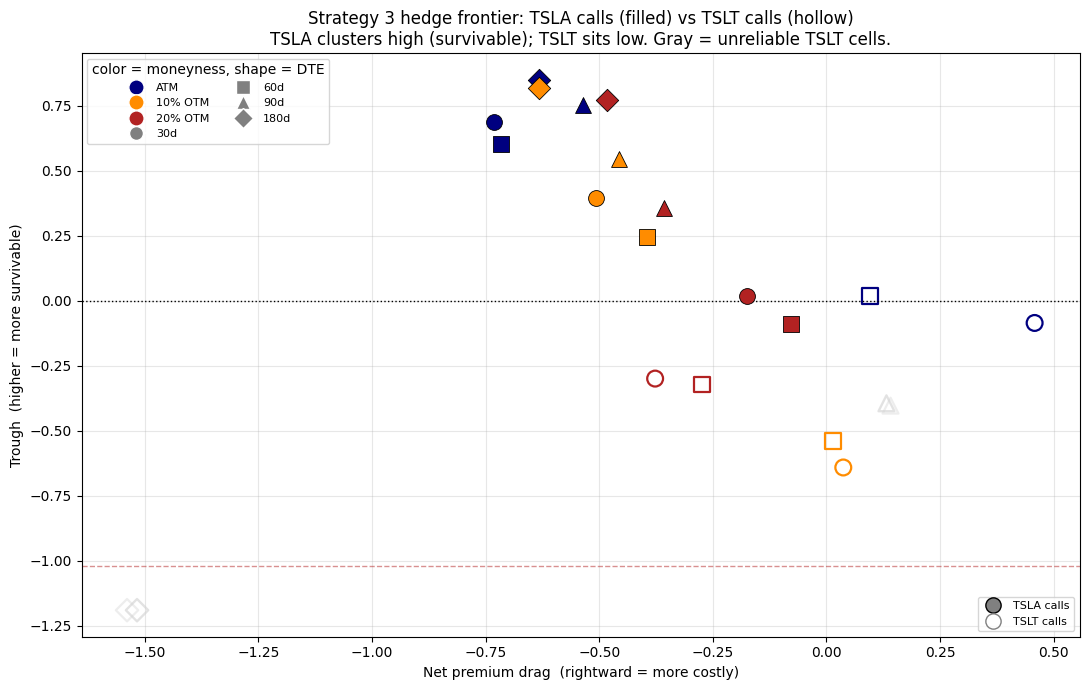

In [40]:
# -----------------------------------------------------------------------------
# 6. COMPARISON PLOT — TSLA calls (filled) vs TSLT calls (hollow)
#    Requires the TSLA-call `sweep` DataFrame from the earlier session.
# -----------------------------------------------------------------------------
shape_by_dte = {30: "o", 60: "s", 90: "^", 180: "D"}
color_by_mny = {"ATM": "navy", "10% OTM": "darkorange", "20% OTM": "firebrick"}

fig, ax = plt.subplots(figsize=(11, 7))

for _, r in sweep.iterrows():                      # TSLA = filled
    ax.scatter(r["Net Drag"], r["Trough"], marker=shape_by_dte[r["DTE"]],
               c=color_by_mny[r["Moneyness"]], s=130, edgecolor="black",
               linewidth=0.6, zorder=3)

for _, r in sweep_tslt.iterrows():                 # TSLT = hollow; gray if unreliable
    bad = not r["Reliable"]
    ax.scatter(r["Net Drag"], r["Trough"], marker=shape_by_dte[r["DTE"]],
               facecolors="none",
               edgecolors=("lightgray" if bad else color_by_mny[r["Moneyness"]]),
               s=130, linewidth=1.6, alpha=(0.4 if bad else 1.0), zorder=2)

ax.axhline(0, color="black", lw=1, ls=":")
ax.axhline(naked_h.min(), color="firebrick", lw=1, ls="--", alpha=0.5)
ax.set_xlabel("Net premium drag  (rightward = more costly)")
ax.set_ylabel("Trough  (higher = more survivable)")
ax.set_title("Strategy 3 hedge frontier: TSLA calls (filled) vs TSLT calls (hollow)\n"
             "TSLA clusters high (survivable); TSLT sits low. Gray = unreliable TSLT cells.")
ax.grid(alpha=0.3)

from matplotlib.lines import Line2D
leg_mny = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=11, label=m)
           for m, c in color_by_mny.items()]
leg_dte = [Line2D([0],[0], marker=mk, color='w', markerfacecolor='grey', markersize=10, label=f'{d}d')
           for d, mk in shape_by_dte.items()]
leg_fill = [Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',
                   markeredgecolor='black', markersize=11, label='TSLA calls'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='none',
                   markeredgecolor='grey', markersize=11, label='TSLT calls')]
leg1 = ax.legend(handles=leg_mny+leg_dte, fontsize=8, ncol=2, loc="upper left",
                 title="color = moneyness, shape = DTE")
ax.add_artist(leg1)
ax.legend(handles=leg_fill, fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("tsla_vs_tslt_call_hedge.png", dpi=130)
plt.show()

Naked short trough — TSLA window: -0.688 | TSLT window: -1.021

=== TSLA calls ===
instrument  coverage  return_%  trough  net_drag
TSLA calls      2.00      93.0   0.603    -0.717
TSLA calls      2.25     102.4   0.765    -0.807
TSLA calls      2.50     111.8   0.815    -0.897
TSLA calls      2.75     121.1   0.830    -0.986
TSLA calls      3.00     130.5   0.836    -1.076
TSLA calls      3.25     139.9   0.838    -1.165
TSLA calls      3.50     149.3   0.834    -1.255
TSLA calls      3.75     158.7   0.815    -1.345
TSLA calls      4.00     168.0   0.765    -1.434

=== TSLT calls ===
instrument  coverage  return_%  trough  net_drag
TSLT calls      2.00      31.0   0.018     0.096
TSLT calls      2.25      33.9  -0.019     0.108
TSLT calls      2.50      36.8  -0.056     0.120
TSLT calls      2.75      39.7  -0.093     0.132
TSLT calls      3.00      42.6  -0.130     0.143
TSLT calls      3.25      45.5  -0.167     0.155
TSLT calls      3.50      48.4  -0.204     0.167
TSLT calls     

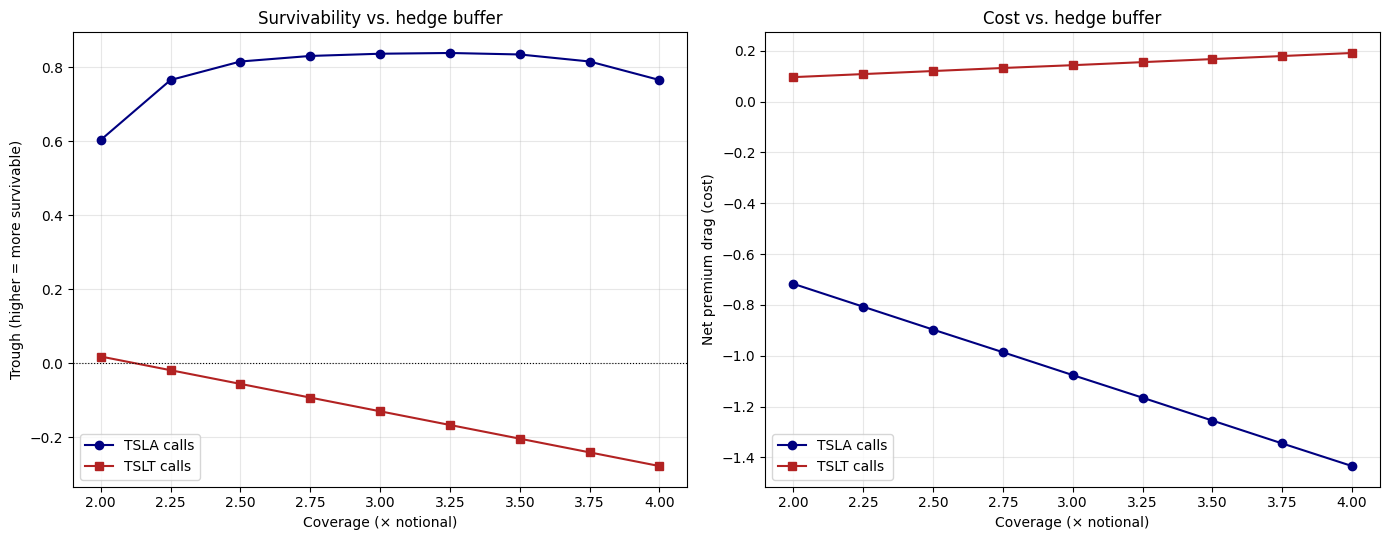

In [41]:
# ============================================================
# BUFFER EXPERIMENT — hedge coverage > 2x, TSLA calls vs TSLT calls
# Base spec: 60-day ATM, gross of borrow. Coverage 2.0 -> 4.0 in 0.25 steps.
# Uses the generalized engine: build_hedge_schedule_g, run_strategy3_g.
# ============================================================
coverage_grid = np.arange(2.0, 4.01, 0.25)

def buffer_sweep(opt_table, spot, label):
    # schedule is independent of coverage, so build it once
    sched = build_hedge_schedule_g(opt_table, spot, target_dte=60, moneyness=0.0)
    fv = sched["call_px"].first_valid_index()
    sched = sched.loc[fv:]
    naked = 2 - (px3[LETF].reindex(sched.index) / px3[LETF].reindex(sched.index).iloc[0])
    out = []
    for cov in coverage_grid:
        eq, det = run_strategy3_g(sched, opt_table, coverage=cov, borrow_tslt=0.0)
        out.append({
            "instrument": label,
            "coverage": round(cov, 2),
            "return_%": round((eq.iloc[-1]-1)*100, 1),
            "trough":   round(eq.min(), 3),
            "net_drag": round(det["prem_paid"].sum() - det["prem_recd"].sum(), 3),
        })
    return pd.DataFrame(out), sched.index, naked.min()

# spot series matched to each option table's window
spot_tsla = px3[UNDER].loc[opt["date"].min():]

buf_tsla, idx_tsla, naked_tsla = buffer_sweep(opt,      spot_tsla, "TSLA calls")
buf_tslt, idx_tslt, naked_tslt = buffer_sweep(opt_tslt, spot_tslt, "TSLT calls")

print("Naked short trough — TSLA window:", round(naked_tsla, 3),
      "| TSLT window:", round(naked_tslt, 3))
print("\n=== TSLA calls ===")
print(buf_tsla.to_string(index=False))
print("\n=== TSLT calls ===")
print(buf_tslt.to_string(index=False))

# best coverage by max trough (survivability) for each instrument
best_tsla = buf_tsla.loc[buf_tsla["trough"].idxmax()]
best_tslt = buf_tslt.loc[buf_tslt["trough"].idxmax()]
print(f"\nBest coverage (max trough) — TSLA: {best_tsla['coverage']} "
      f"(trough {best_tsla['trough']}, drag {best_tsla['net_drag']})")
print(f"Best coverage (max trough) — TSLT: {best_tslt['coverage']} "
      f"(trough {best_tslt['trough']}, drag {best_tslt['net_drag']})")

# ---------------- plots ----------------
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: survivability (trough) vs coverage
ax[0].plot(buf_tsla["coverage"], buf_tsla["trough"], "o-", color="navy",     label="TSLA calls")
ax[0].plot(buf_tslt["coverage"], buf_tslt["trough"], "s-", color="firebrick", label="TSLT calls")
ax[0].axhline(0, color="black", lw=0.8, ls=":")
ax[0].set_xlabel("Coverage (× notional)")
ax[0].set_ylabel("Trough (higher = more survivable)")
ax[0].set_title("Survivability vs. hedge buffer")
ax[0].legend(); ax[0].grid(alpha=0.3)

# Panel 2: cost (net premium drag) vs coverage
ax[1].plot(buf_tsla["coverage"], buf_tsla["net_drag"], "o-", color="navy",     label="TSLA calls")
ax[1].plot(buf_tslt["coverage"], buf_tslt["net_drag"], "s-", color="firebrick", label="TSLT calls")
ax[1].set_xlabel("Coverage (× notional)")
ax[1].set_ylabel("Net premium drag (cost)")
ax[1].set_title("Cost vs. hedge buffer")
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Trying a basket of options

In [43]:
# ============================================================
# STEP 1 — Back out Black-Scholes implied volatility from TSLA option prices
# ============================================================
from scipy.stats import norm
from scipy.optimize import brentq

RISK_FREE = 0.045    # ~4.5% short rate over the 2023-2026 window (approx)

def bs_call_price(S, K, T, r, sigma):
    """Black-Scholes European call price."""
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def implied_vol(price, S, K, T, r):
    """Invert BS to find IV. Returns NaN if no sensible solution."""
    intrinsic = max(S - K, 0.0)
    # price must exceed intrinsic and be below spot for a valid IV
    if T <= 0 or price <= intrinsic + 1e-6 or price >= S:
        return np.nan
    try:
        return brentq(lambda sig: bs_call_price(S, K, T, r, sig) - price,
                      1e-4, 5.0, maxiter=100, xtol=1e-6)
    except (ValueError, RuntimeError):
        return np.nan

# --- Test on a small, well-behaved sample first ---
# Use a single date with liquid contracts, TSLA spot from px3
test_date = pd.Timestamp("2024-06-03")   # a roll date we know exists
S_test = px3[UNDER].loc[test_date]

sample = opt[opt["date"] == test_date].copy()
sample["T"] = (sample["expiry"] - sample["date"]).dt.days / 365.0
sample["iv"] = sample.apply(
    lambda row: implied_vol(row["px_last"], S_test, row["strike"], row["T"], RISK_FREE),
    axis=1
)
sample["moneyness"] = sample["strike"] / S_test - 1

print(f"Test date {test_date.date()}, TSLA spot = {S_test:.2f}")
print(f"Contracts: {len(sample)}, IV computed: {sample['iv'].notna().sum()}, NaN: {sample['iv'].isna().sum()}")
print("\nIV by moneyness (near-the-money slice):")
near = sample[(sample["moneyness"].abs() < 0.25) & sample["iv"].notna()].sort_values("strike")
print(near[["strike","T","px_last","moneyness","iv"]].head(20).to_string(index=False))

print(f"\nIV summary (valid only): min {sample['iv'].min():.3f}, "
      f"median {sample['iv'].median():.3f}, max {sample['iv'].max():.3f}")

Test date 2024-06-03, TSLA spot = 176.29
Contracts: 373, IV computed: 373, NaN: 0

IV by moneyness (near-the-money slice):
 strike        T  px_last  moneyness       iv
 145.00 0.049315    32.40  -0.177492 0.628650
 145.00 0.202740    36.57  -0.177492 0.522662
 145.00 0.126027    35.00  -0.177492 0.582868
 145.00 0.298630    39.15  -0.177492 0.515568
 150.00 0.049315    27.25  -0.149129 0.513628
 150.00 0.126027    30.00  -0.149129 0.512954
 150.00 0.298630    36.20  -0.149129 0.533855
 150.00 0.202740    33.23  -0.149129 0.539730
 153.33 0.049315    24.30  -0.130240 0.519431
 155.00 0.126027    25.30  -0.120767 0.461946
 155.00 0.298630    34.40  -0.120767 0.578879
 155.00 0.202740    29.95  -0.120767 0.546417
 155.00 0.049315    22.80  -0.120767 0.512694
 156.67 0.049315    21.35  -0.111294 0.509094
 160.00 0.298630    29.34  -0.092405 0.515632
 160.00 0.049315    18.15  -0.092405 0.459760
 160.00 0.202740    25.98  -0.092405 0.517786
 160.00 0.126027    22.27  -0.092405 0.494574
 16

In [44]:
# ============================================================
# STEP 2 — Black-Scholes delta from the backed-out IV
# ============================================================
def bs_call_delta(S, K, T, r, sigma):
    """Delta of a European call. ~0.5 ATM, ->1 deep ITM, ->0 deep OTM."""
    if T <= 0 or sigma <= 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.cdf(d1)

# add delta to the test sample
sample["delta"] = sample.apply(
    lambda row: bs_call_delta(S_test, row["strike"], row["T"], RISK_FREE, row["iv"])
    if not np.isnan(row["iv"]) else np.nan,
    axis=1
)

# --- Sanity check Nitesh's prediction: what coverage does delta-matching imply? ---
# Short $1 TSLT = -2x TSLA delta exposure. To offset with calls of delta d,
# required NOTIONAL coverage = 2 / d  (since each $1 notional gives delta d of exposure).
# ATM (d~0.5) -> coverage ~4x. Further OTM (lower d) -> higher coverage.

# pick contracts near a ~60-day expiry to mimic the strategy
sixty = sample[(sample["T"]*365 > 45) & (sample["T"]*365 < 75)].copy()
sixty["req_coverage"] = 2.0 / sixty["delta"]     # notional needed to delta-match

print(f"~60-day contracts on {test_date.date()}, spot {S_test:.2f}:\n")
show = sixty[(sixty["moneyness"] > -0.02)].sort_values("strike")   # ATM and OTM
print(show[["strike","moneyness","T","iv","delta","req_coverage"]].head(20).to_string(index=False))

~60-day contracts on 2024-06-03, spot 176.29:

 strike  moneyness        T       iv    delta  req_coverage
  175.0  -0.007317 0.126027 0.501232 0.564393      3.543632
  175.0  -0.007317 0.202740 0.519200 0.574299      3.482505
  180.0   0.021045 0.126027 0.497115 0.500942      3.992476
  180.0   0.021045 0.202740 0.522883 0.527111      3.794267
  185.0   0.049407 0.126027 0.497178 0.439258      4.553132
  185.0   0.049407 0.202740 0.522403 0.480609      4.161390
  190.0   0.077770 0.126027 0.488959 0.377521      5.297716
  190.0   0.077770 0.202740 0.521342 0.435334      4.594171
  195.0   0.106132 0.126027 0.499186 0.326864      6.118760
  195.0   0.106132 0.202740 0.516481 0.390415      5.122753
  200.0   0.134494 0.202740 0.522494 0.351988      5.682017
  200.0   0.134494 0.126027 0.499554 0.277297      7.212483
  205.0   0.162857 0.202740 0.520344 0.312813      6.393592
  205.0   0.162857 0.126027 0.503213 0.234679      8.522274
  210.0   0.191219 0.202740 0.525899 0.280278      7.

In [45]:
# ============================================================
# STEP 3 — Delta-matched Strategy 3 engine (roll-sized AND daily-resized)
# Hedge sized so call position's dollar-delta offsets the short's -2x TSLA delta.
# Needs: implied_vol(), bs_call_delta() from Steps 1-2; opt (TSLA calls); px3.
# ============================================================

def _iv_delta_for(opt_table, d, S, key, r=RISK_FREE):
    """Return (price, delta) for a specific (expiry,strike) contract on date d."""
    exp, strk = key
    m = opt_table[(opt_table["date"] == d) & (opt_table["expiry"] == exp) & (opt_table["strike"] == strk)]
    if m.empty:
        return np.nan, np.nan
    price = m["px_last"].iloc[0]
    T = (exp - d).days / 365.0
    iv = implied_vol(price, S, strk, T, r)
    if np.isnan(iv):
        # fall back to intrinsic-based delta if inversion fails (deep ITM/OTM)
        delta = 1.0 if S > strk else 0.0
    else:
        delta = bs_call_delta(S, strk, T, r, iv)
    return price, delta


def run_strategy3_delta(sched, opt_table, target_delta_exposure=2.0,
                        resize="roll", borrow_tslt=0.0, r=RISK_FREE):
    """
    Static short $1 TSLT + long TSLA calls sized to DELTA target.
      target_delta_exposure : dollar-delta to offset (2.0 = full -2x TSLA short)
      resize : "roll"  -> set share count at each roll, hold till next roll
               "daily" -> recompute delta and reset share count every day
    Equity = 1 + cum_short_pnl + cum_call_pnl - cum_borrow (exact premium acct).
    """
    dates = sched.index
    tslt_g = px3[LETF].reindex(dates) / px3[LETF].reindex(dates).iloc[0]
    cum_short_pnl = -(tslt_g - 1.0)

    cash_opt = 0.0
    call_shares = 0.0
    held_key = None
    cum_borrow = 0.0
    equity = pd.Series(index=dates, dtype=float)
    rows = []

    for j, d in enumerate(dates):
        row = sched.loc[d]
        S, cpx = row["spot"], row["call_px"]
        key = (row["expiry"], row["strike"])

        # current delta of the held/target contract
        _, delta_now = _iv_delta_for(opt_table, d, S, key, r)
        if np.isnan(delta_now) or delta_now <= 1e-6:
            delta_now = 1.0 if S > key[1] else 0.01   # guard

        prem_paid = prem_recd = 0.0
        rolled = (key != held_key)

        # desired share count to hit delta target: shares * delta * S = target
        desired_shares = target_delta_exposure / (delta_now * S)

        if rolled:
            # sell old contract entirely, buy new at desired delta-sized qty
            if held_key is not None:
                old_px, _ = _iv_delta_for(opt_table, d, S, held_key, r)
                if np.isnan(old_px): old_px = cpx
                prem_recd = call_shares * old_px
                cash_opt += prem_recd
            call_shares = desired_shares
            prem_paid = call_shares * cpx
            cash_opt -= prem_paid
            held_key = key
        elif resize == "daily":
            # adjust share count to re-hit delta target (buy or sell the delta)
            d_shares = desired_shares - call_shares
            # cash flow: buying more costs premium, selling returns it (at today's px)
            cash_opt -= d_shares * cpx
            if d_shares > 0: prem_paid = d_shares * cpx
            else:            prem_recd = -d_shares * cpx
            call_shares = desired_shares

        call_value = call_shares * cpx
        cum_call_pnl = cash_opt + call_value
        cum_borrow += tslt_g.iloc[j] * borrow_tslt / 252
        equity.loc[d] = 1.0 + cum_short_pnl.iloc[j] + cum_call_pnl - cum_borrow
        rows.append((d, cum_short_pnl.iloc[j], cum_call_pnl, call_value,
                     prem_paid, prem_recd, call_shares, delta_now, S, cpx))

    detail = pd.DataFrame(rows, columns=["date","cum_short_pnl","cum_call_pnl","call_value",
                                         "prem_paid","prem_recd","call_shares","delta","spot","call_px"]).set_index("date")
    return equity, detail


# --- Test both on 60-day ATM TSLA calls, delta-matched ---
sched_test = build_hedge_schedule_g(opt, spot_tsla, target_dte=60, moneyness=0.0)
fv = sched_test["call_px"].first_valid_index()
sched_test = sched_test.loc[fv:]
naked_test = 2 - (px3[LETF].reindex(sched_test.index) / px3[LETF].reindex(sched_test.index).iloc[0])

eq_roll,  det_roll  = run_strategy3_delta(sched_test, opt, resize="roll")
eq_daily, det_daily = run_strategy3_delta(sched_test, opt, resize="daily")

print("Delta-matched Strategy 3 — 60-day ATM TSLA calls (gross)\n")
print(f"  Naked short:          return {(naked_test.iloc[-1]-1)*100:7.2f}%   trough {naked_test.min():.3f}")
print(f"  Delta-matched (roll):  return {(eq_roll.iloc[-1]-1)*100:7.2f}%   trough {eq_roll.min():.3f}   "
      f"net drag {det_roll['prem_paid'].sum()-det_roll['prem_recd'].sum():.3f}")
print(f"  Delta-matched (daily): return {(eq_daily.iloc[-1]-1)*100:7.2f}%   trough {eq_daily.min():.3f}   "
      f"net drag {det_daily['prem_paid'].sum()-det_daily['prem_recd'].sum():.3f}")

# implied coverage the delta-sizing chose (sanity vs Nitesh's ~4x)
avg_cov_roll = (det_roll["call_shares"] * det_roll["spot"] / 2.0).mean()   # notional/2 = coverage multiple
print(f"\n  Avg implied coverage (roll): {avg_cov_roll:.2f}x   ")
print(f"  Avg delta held (roll): {det_roll['delta'].mean():.3f}")

Delta-matched Strategy 3 — 60-day ATM TSLA calls (gross)

  Naked short:          return   17.97%   trough -0.688
  Delta-matched (roll):  return  155.52%   trough 0.832   net drag -1.312
  Delta-matched (daily): return  180.13%   trough 0.736   net drag -1.450

  Avg implied coverage (roll): 1.81x   
  Avg delta held (roll): 0.517


In [46]:
# correct coverage diagnostic: notional held / $1 short = call_shares * spot / 1.0
det_roll["notional_cov"] = det_roll["call_shares"] * det_roll["spot"]   # $ notional of calls
print("True avg notional coverage (roll):", round(det_roll["notional_cov"].mean(), 2), "x")
print("Implied by delta formula (2/delta):", round((2/det_roll['delta']).mean(), 2), "x")
print("Avg delta:", round(det_roll["delta"].mean(), 3))

# spot-check one row
r0 = det_roll.iloc[10]
print(f"\nRow check: shares={r0['call_shares']:.4f}, spot={r0['spot']:.2f}, "
      f"notional={r0['call_shares']*r0['spot']:.2f}, delta={r0['delta']:.3f}, "
      f"dollar-delta={r0['call_shares']*r0['delta']*r0['spot']:.3f}")

True avg notional coverage (roll): 3.61 x
Implied by delta formula (2/delta): 7.47 x
Avg delta: 0.517

Row check: shares=0.0164, spot=218.51, notional=3.58, delta=0.528, dollar-delta=1.892


In [47]:
def trough_and_mdd(eq):
    trough = eq.min()
    mdd = (eq / eq.cummax() - 1).min()
    return round(trough, 3), round(mdd*100, 1)

for name, eq in [("Naked short", naked_test), ("Delta (roll)", eq_roll), ("Delta (daily)", eq_daily)]:
    tr, mdd = trough_and_mdd(eq)
    print(f"{name:16s}  trough {tr:7.3f}   maxDD {mdd:7.1f}%")

Naked short       trough  -0.688   maxDD  -141.6%
Delta (roll)      trough   0.832   maxDD   -30.4%
Delta (daily)     trough   0.736   maxDD   -29.8%


In [48]:
# ============================================================
# BASKET delta-matched Strategy 3 — ATM + 10% + 20% OTM, equal-delta split
# Each of 3 legs supplies 1/3 of the -2.0 dollar-delta target.
# Roll-sized (set shares at each roll, per the winning roll-sizing result).
# ============================================================

def build_basket_schedule(opt_table, spot, target_dte, moneyness_legs=(0.0, 0.10, 0.20),
                          roll_buffer=20, max_dte_mult=2.0):
    """
    Like build_hedge_schedule_g but tracks a BASKET of legs (one per moneyness).
    Returns a schedule where each row carries a list of (expiry, strike, px) per leg.
    Rolls all legs together when the front contract nears expiry.
    """
    dates = spot.index
    rows = []
    held = None   # list of (expiry, strike) per leg

    for d in dates:
        S = spot.loc[d]
        day_opts = opt_table[opt_table["date"] == d]
        if day_opts.empty:
            rows.append((d, held, S, False)); continue

        need_new = held is None or (held[0][0] - d).days <= roll_buffer
        if need_new:
            dte_all = (day_opts["expiry"] - d).dt.days
            exp_pool = day_opts[(dte_all > roll_buffer) & (dte_all <= max_dte_mult*target_dte)]["expiry"].unique()
            if len(exp_pool) == 0:
                rows.append((d, held, S, False)); continue
            target_date = d + pd.Timedelta(days=target_dte)
            chosen_exp = pd.Timestamp(min(exp_pool, key=lambda e: abs((pd.Timestamp(e)-target_date).days)))
            exp_strikes = day_opts[day_opts["expiry"] == chosen_exp]
            legs = []
            for mny in moneyness_legs:
                tgt = S * (1 + mny)
                k = exp_strikes.iloc[(exp_strikes["strike"] - tgt).abs().argsort().iloc[0]]["strike"]
                legs.append((chosen_exp, k))
            held = legs
            rolled = True
        else:
            rolled = False
        rows.append((d, held, S, rolled))

    return pd.DataFrame(rows, columns=["date","legs","spot","rolled"]).set_index("date")


def run_basket_delta(sched, opt_table, target_delta_exposure=2.0, r=RISK_FREE, borrow_tslt=0.0):
    """Static short $1 TSLT + basket of calls, each leg sized to 1/N of the delta target."""
    dates = sched.index
    tslt_g = px3[LETF].reindex(dates) / px3[LETF].reindex(dates).iloc[0]
    cum_short_pnl = -(tslt_g - 1.0)

    cash_opt = 0.0
    held_shares = None      # shares per leg
    held_legs = None
    cum_borrow = 0.0
    equity = pd.Series(index=dates, dtype=float)
    rows = []

    for j, d in enumerate(dates):
        row = sched.loc[d]
        S = row["spot"]; legs = row["legs"]
        if legs is None:
            equity.iloc[j] = 1.0 + cum_short_pnl.iloc[j]; continue

        n_legs = len(legs)
        per_leg_delta_target = target_delta_exposure / n_legs   # 2/3 each

        # price + delta of each leg today
        leg_px, leg_delta = [], []
        for (exp, k) in legs:
            px, dl = _iv_delta_for(opt_table, d, S, (exp, k), r)
            if np.isnan(px): px = 0.01
            if np.isnan(dl) or dl <= 1e-6: dl = 1.0 if S > k else 0.01
            leg_px.append(px); leg_delta.append(dl)

        prem_paid = prem_recd = 0.0
        if row["rolled"] or held_shares is None:
            # sell old basket
            if held_legs is not None:
                for (exp,k), sh in zip(held_legs, held_shares):
                    opx, _ = _iv_delta_for(opt_table, d, S, (exp,k), r)
                    if np.isnan(opx): opx = 0.01
                    prem_recd += sh * opx
                cash_opt += prem_recd
            # size each leg to its 1/N dollar-delta target: sh*delta*S = per_leg_target
            held_shares = [per_leg_delta_target / (dl * S) for dl in leg_delta]
            for sh, px in zip(held_shares, leg_px):
                prem_paid += sh * px
            cash_opt -= prem_paid
            held_legs = legs

        # mark basket to market
        basket_value = sum(sh * px for sh, px in zip(held_shares, leg_px))
        basket_delta = sum(sh * dl * S for sh, dl in zip(held_shares, leg_delta))  # dollar-delta
        cum_call_pnl = cash_opt + basket_value
        cum_borrow += tslt_g.iloc[j] * borrow_tslt / 252
        equity.iloc[j] = 1.0 + cum_short_pnl.iloc[j] + cum_call_pnl - cum_borrow
        rows.append((d, cum_call_pnl, basket_value, basket_delta, prem_paid, prem_recd, S))

    detail = pd.DataFrame(rows, columns=["date","cum_call_pnl","basket_value","basket_dollar_delta",
                                         "prem_paid","prem_recd","spot"]).set_index("date")
    return equity, detail


# --- Run the basket, 60-day, and compare to single-strike delta-matched ---
sched_basket = build_basket_schedule(opt, spot_tsla, target_dte=60)
# trim to first day all legs exist
first_valid = sched_basket["legs"].first_valid_index()
sched_basket = sched_basket.loc[first_valid:]

eq_basket, det_basket = run_basket_delta(sched_basket, opt)
naked_b = 2 - (px3[LETF].reindex(sched_basket.index) / px3[LETF].reindex(sched_basket.index).iloc[0])

def trough_mdd(eq):
    return round(eq.min(),3), round((eq/eq.cummax()-1).min()*100,1)

print("Basket (ATM+10%+20% OTM, equal-delta) vs single-strike delta-matched — 60d, gross\n")
tb, mb = trough_mdd(eq_basket)
print(f"  Naked short:            trough {naked_b.min():.3f}")
print(f"  Single-strike (roll):   trough 0.832   maxDD -30.4%   (from before)")
print(f"  BASKET:                 trough {tb:7.3f}   maxDD {mb:6.1f}%   "
      f"return {(eq_basket.iloc[-1]-1)*100:.1f}%   net drag {det_basket['prem_paid'].sum()-det_basket['prem_recd'].sum():.3f}")

# CRITICAL sanity check: does the basket's dollar-delta actually hit ~2.0?
print(f"\n  Avg basket dollar-delta: {det_basket['basket_dollar_delta'].mean():.3f}  (target 2.0)")
print(f"  Min/Max basket dollar-delta: {det_basket['basket_dollar_delta'].min():.2f} / {det_basket['basket_dollar_delta'].max():.2f}")

Basket (ATM+10%+20% OTM, equal-delta) vs single-strike delta-matched — 60d, gross

  Naked short:            trough -0.688
  Single-strike (roll):   trough 0.832   maxDD -30.4%   (from before)
  BASKET:                 trough   0.692   maxDD  -46.6%   return 136.9%   net drag -1.138

  Avg basket dollar-delta: 2.026  (target 2.0)
  Min/Max basket dollar-delta: 0.03 / 8.29


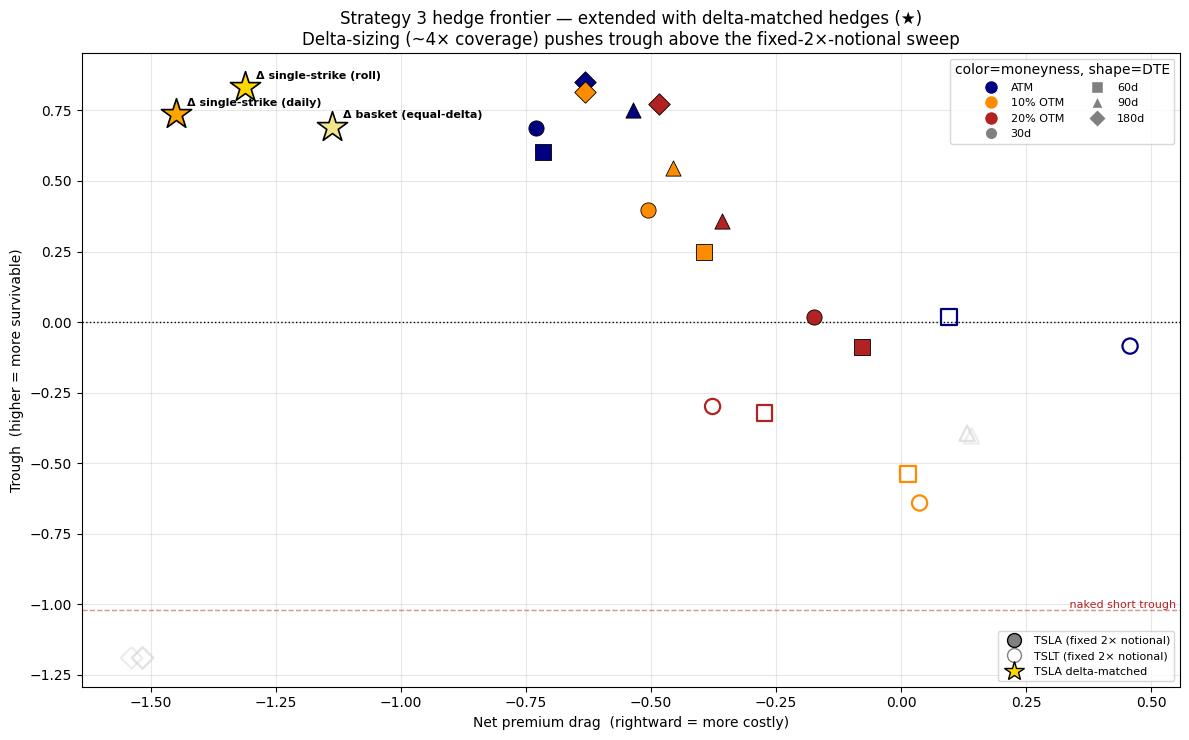

Delta-matched points (drag, trough):
  Δ single-strike (roll)      drag  -1.312   trough 0.832
  Δ single-strike (daily)     drag  -1.450   trough 0.736
  Δ basket (equal-delta)      drag  -1.138   trough 0.692


In [49]:
# ============================================================
# EXTENDED FRONTIER: add delta-matched hedges to the TSLA/TSLT scatter
# ============================================================
shape_by_dte = {30: "o", 60: "s", 90: "^", 180: "D"}
color_by_mny = {"ATM": "navy", "10% OTM": "darkorange", "20% OTM": "firebrick"}

def _pt(eq, det):
    trough = eq.min()
    drag = det["prem_paid"].sum() - det["prem_recd"].sum()
    return drag, trough

# delta-matched points (all 60d ATM, TSLA calls, delta-sized ~4x coverage)
delta_pts = {
    "Δ single-strike (roll)":  _pt(eq_roll,  det_roll),
    "Δ single-strike (daily)": _pt(eq_daily, det_daily),
    "Δ basket (equal-delta)":  _pt(eq_basket, det_basket),
}

fig, ax = plt.subplots(figsize=(12, 7.5))

# --- existing sweep: TSLA filled, TSLT hollow (grey if unreliable) ---
for _, r in sweep.iterrows():
    ax.scatter(r["Net Drag"], r["Trough"], marker=shape_by_dte[r["DTE"]],
               c=color_by_mny[r["Moneyness"]], s=120, edgecolor="black", linewidth=0.6, zorder=3)
for _, r in sweep_tslt.iterrows():
    bad = not r["Reliable"]
    ax.scatter(r["Net Drag"], r["Trough"], marker=shape_by_dte[r["DTE"]],
               facecolors="none",
               edgecolors=("lightgray" if bad else color_by_mny[r["Moneyness"]]),
               s=120, linewidth=1.6, alpha=(0.4 if bad else 1.0), zorder=2)

# --- delta-matched points: gold stars, annotated ---
star_colors = {"Δ single-strike (roll)": "gold",
               "Δ single-strike (daily)": "orange",
               "Δ basket (equal-delta)": "khaki"}
for label, (drag, trough) in delta_pts.items():
    ax.scatter(drag, trough, marker="*", s=520, c=star_colors[label],
               edgecolor="black", linewidth=1.2, zorder=5)
    ax.annotate(label, (drag, trough), fontsize=8, fontweight="bold",
                xytext=(8, 6), textcoords="offset points")

# reference lines
ax.axhline(0, color="black", lw=1, ls=":")
ax.axhline(naked_h.min(), color="firebrick", lw=1, ls="--", alpha=0.5)
ax.text(ax.get_xlim()[1], naked_h.min(), " naked short trough ", fontsize=8,
        color="firebrick", va="bottom", ha="right")

ax.set_xlabel("Net premium drag  (rightward = more costly)")
ax.set_ylabel("Trough  (higher = more survivable)")
ax.set_title("Strategy 3 hedge frontier — extended with delta-matched hedges (★)\n"
             "Delta-sizing (~4× coverage) pushes trough above the fixed-2×-notional sweep")
ax.grid(alpha=0.3)

from matplotlib.lines import Line2D
leg_mny = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=10, label=m)
           for m, c in color_by_mny.items()]
leg_dte = [Line2D([0],[0], marker=mk, color='w', markerfacecolor='grey', markersize=9, label=f'{d}d')
           for d, mk in shape_by_dte.items()]
leg_type = [Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markeredgecolor='black', markersize=10, label='TSLA (fixed 2× notional)'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='none', markeredgecolor='grey', markersize=10, label='TSLT (fixed 2× notional)'),
            Line2D([0],[0], marker='*', color='w', markerfacecolor='gold', markeredgecolor='black', markersize=15, label='TSLA delta-matched')]

# both legends on the right, stacked
leg1 = ax.legend(handles=leg_mny+leg_dte, fontsize=8, ncol=2, loc="upper right",
                 title="color=moneyness, shape=DTE")
ax.add_artist(leg1)
ax.legend(handles=leg_type, fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("frontier_extended_delta.png", dpi=130)
plt.show()

# print the star coords for reference
print("Delta-matched points (drag, trough):")
for k, v in delta_pts.items():
    print(f"  {k:26s}  drag {v[0]:7.3f}   trough {v[1]:.3f}")

## Finding optimal basket

In [51]:
# ============================================================
# BASKET OPTIMIZER — per-roll LP: min premium s.t. delta=2, gamma>=ATM-gamma
# ============================================================
from scipy.optimize import linprog

def bs_gamma(S, K, T, r, sigma):
    """Black-Scholes gamma."""
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def option_greeks(price, S, K, T, r):
    """Return (iv, delta, gamma) for one option from its market price."""
    iv = implied_vol(price, S, K, T, r)
    if np.isnan(iv):
        delta = 1.0 if S > K else 0.0
        return np.nan, delta, 0.0
    delta = bs_call_delta(S, K, T, r, iv)
    gamma = bs_gamma(S, K, T, r, iv)
    return iv, delta, gamma

def optimize_basket(day_chain, S, expiry, target_delta=2.0, r=RISK_FREE):
    """
    LP at one roll: choose contracts n_i >= 0 across all strikes at `expiry` to
      minimize   sum(price_i * n_i)
      s.t.       sum(delta_i * S * n_i) = target_delta      (dollar-delta match)
                 sum(gamma_i * n_i)     >= gamma_target      (>= single-ATM gamma)
    gamma_target = gamma of the single-strike ATM delta-matched position.
    Returns dict: strikes, shares, total_premium, achieved delta/gamma.
    """
    chain = day_chain[day_chain["expiry"] == expiry].copy()
    if chain.empty:
        return None
    T = (expiry - chain["date"].iloc[0]).days / 365.0

    # greeks for every strike
    recs = []
    for _, row in chain.iterrows():
        iv, dl, gm = option_greeks(row["px_last"], S, row["strike"], T, r)
        if dl > 1e-6:                     # skip zero-delta junk
            recs.append((row["strike"], row["px_last"], dl, gm))
    if not recs:
        return None
    K  = np.array([x[0] for x in recs])
    px = np.array([x[1] for x in recs])
    dl = np.array([x[2] for x in recs])
    gm = np.array([x[3] for x in recs])

    # --- benchmark: single-strike ATM position's delta & gamma ---
    atm_i = np.argmin(np.abs(K - S))                 # nearest-ATM strike
    atm_shares = target_delta / (dl[atm_i] * S)      # shares to hit delta target with ATM alone
    gamma_target = atm_shares * gm[atm_i]            # gamma the ATM hedge would have

    # --- LP: min px @ n  s.t.  (delta*S) @ n == target_delta ; (gamma) @ n >= gamma_target ; n>=0 ---
    A_eq = (dl * S).reshape(1, -1);  b_eq = [target_delta]
    A_ub = (-gm).reshape(1, -1);     b_ub = [-gamma_target]   # -gamma@n <= -gamma_target  <=>  gamma@n >= target
    res = linprog(c=px, A_eq=A_eq, b_eq=b_eq, A_ub=A_ub, b_ub=b_ub,
                  bounds=[(0, None)]*len(px), method="highs")
    if not res.success:
        return None

    n = res.x
    used = n > 1e-6
    return {
        "strikes": K[used], "shares": n[used], "prices": px[used],
        "deltas": dl[used], "gammas": gm[used],
        "total_premium": float(px @ n),
        "achieved_dollar_delta": float((dl * S) @ n),
        "achieved_gamma": float(gm @ n),
        "gamma_target": gamma_target,
        "atm_only_premium": atm_shares * px[atm_i],   # cost of the single-ATM benchmark
        "n_strikes_used": int(used.sum()),
    }

# --- TEST on a single roll date ---
test_date = pd.Timestamp("2024-06-03")
S_t = px3[UNDER].loc[test_date]
chain_t = opt[opt["date"] == test_date].copy()
# pick the ~60-day expiry available that day
exps = chain_t["expiry"].unique()
target_exp = pd.Timestamp(min(exps, key=lambda e: abs(((pd.Timestamp(e)-test_date).days) - 60)))

sol = optimize_basket(chain_t, S_t, target_exp)
print(f"Roll date {test_date.date()}, spot {S_t:.2f}, expiry {target_exp.date()}\n")
print(f"Strikes used ({sol['n_strikes_used']}):")
for k, sh, p, d, g in zip(sol["strikes"], sol["shares"], sol["prices"], sol["deltas"], sol["gammas"]):
    print(f"  K={k:6.1f}  shares={sh:6.3f}  px={p:5.2f}  delta={d:.3f}  gamma={g:.4f}")
print(f"\nAchieved dollar-delta: {sol['achieved_dollar_delta']:.3f} (target 2.0)")
print(f"Achieved gamma:        {sol['achieved_gamma']:.4f} (target {sol['gamma_target']:.4f})")
print(f"Basket premium:        {sol['total_premium']:.3f}")
print(f"Single-ATM premium:    {sol['atm_only_premium']:.3f}")
print(f"Basket cheaper by:     {(sol['atm_only_premium']-sol['total_premium']):.3f} "
      f"({(1-sol['total_premium']/sol['atm_only_premium'])*100:.1f}%)")

Roll date 2024-06-03, spot 176.29, expiry 2024-07-19

Strikes used (1):
  K= 270.0  shares= 0.381  px= 0.40  delta=0.030  gamma=0.0018

Achieved dollar-delta: 2.000 (target 2.0)
Achieved gamma:        0.0007 (target 0.0003)
Basket premium:        0.152
Single-ATM premium:    0.273
Basket cheaper by:     0.121 (44.3%)


In [52]:
def optimize_basket_3strike(day_chain, S, expiry, target_delta=2.0, r=RISK_FREE,
                            moneyness_legs=(0.0, 0.10, 0.20)):
    """
    LP at one roll over ONLY the ATM / 10% / 20% OTM strikes at `expiry`.
      min sum(price_i * n_i)  s.t.  sum(delta_i*S*n_i)=target_delta,
                                    sum(gamma_i*n_i) >= gamma_target(ATM-only),  n_i>=0
    """
    chain = day_chain[day_chain["expiry"] == expiry].copy()
    if chain.empty:
        return None
    T = (expiry - chain["date"].iloc[0]).days / 365.0

    # snap to the three target strikes
    recs = []
    for mny in moneyness_legs:
        tgt = S * (1 + mny)
        row = chain.iloc[(chain["strike"] - tgt).abs().argsort().iloc[0]]
        iv, dl, gm = option_greeks(row["px_last"], S, row["strike"], T, r)
        if dl > 1e-6:
            recs.append((row["strike"], row["px_last"], dl, gm, mny))
    # dedupe in case two legs snapped to the same strike (thin chains)
    seen, uniq = set(), []
    for rr in recs:
        if rr[0] not in seen:
            seen.add(rr[0]); uniq.append(rr)
    if not uniq:
        return None
    K  = np.array([x[0] for x in uniq]); px = np.array([x[1] for x in uniq])
    dl = np.array([x[2] for x in uniq]); gm = np.array([x[3] for x in uniq])

    # benchmark gamma = single ATM strike hitting the delta target alone
    atm_i = int(np.argmin(np.abs(K - S)))
    atm_shares = target_delta / (dl[atm_i] * S)
    gamma_target = atm_shares * gm[atm_i]
    atm_only_premium = atm_shares * px[atm_i]

    A_eq = (dl * S).reshape(1, -1); b_eq = [target_delta]
    A_ub = (-gm).reshape(1, -1);    b_ub = [-gamma_target]
    res = linprog(c=px, A_eq=A_eq, b_eq=b_eq, A_ub=A_ub, b_ub=b_ub,
                  bounds=[(0, None)]*len(px), method="highs")
    if not res.success:
        return None
    n = res.x; used = n > 1e-6
    return {
        "strikes": K[used], "shares": n[used], "prices": px[used],
        "moneyness": (K[used]/S - 1),
        "total_premium": float(px @ n),
        "achieved_dollar_delta": float((dl*S) @ n),
        "achieved_gamma": float(gm @ n),
        "gamma_target": gamma_target,
        "atm_only_premium": atm_only_premium,
        "n_strikes_used": int(used.sum()),
    }

# --- re-test on the same date ---
sol = optimize_basket_3strike(chain_t, S_t, target_exp)
print(f"Roll {test_date.date()}, spot {S_t:.2f}, expiry {target_exp.date()}\n")
print(f"Strikes used ({sol['n_strikes_used']}):")
for k, sh, p, m in zip(sol["strikes"], sol["shares"], sol["prices"], sol["moneyness"]):
    print(f"  K={k:6.1f} ({m*100:+.0f}%)  shares={sh:6.3f}  px={p:5.2f}")
print(f"\nAchieved dollar-delta: {sol['achieved_dollar_delta']:.3f} (target 2.0)")
print(f"Achieved gamma:        {sol['achieved_gamma']:.4f} (target {sol['gamma_target']:.4f})")
print(f"Basket premium:        {sol['total_premium']:.3f}")
print(f"Single-ATM premium:    {sol['atm_only_premium']:.3f}")
print(f"Cheaper by:            {(sol['atm_only_premium']-sol['total_premium']):.3f} "
      f"({(1-sol['total_premium']/sol['atm_only_premium'])*100:+.1f}%)")

Roll 2024-06-03, spot 176.29, expiry 2024-07-19

Strikes used (1):
  K= 210.0 (+19%)  shares= 0.058  px= 3.15

Achieved dollar-delta: 2.000 (target 2.0)
Achieved gamma:        0.0005 (target 0.0003)
Basket premium:        0.183
Single-ATM premium:    0.273
Cheaper by:            0.090 (+33.1%)


In [53]:
# ============================================================
# SCENARIO-BASED BASKET OPTIMIZER (per roll)
#   min  sum(price_i * n_i)
#   s.t. for each scenario move m_k:  sum_i n_i * max(S*(1+m_k) - K_i, 0) >= short_loss(m_k)
#        n_i >= 0
#   short_loss(m_k) = 2 * m_k   (short $1 TSLT loses ~2x the TSLA move)
#   Candidates: ALL strikes at the target expiry.
# ============================================================
from scipy.optimize import linprog

SCENARIOS = [0.10, 0.20, 0.30, 0.40]     # adverse TSLA up-moves to cover by expiry

def optimize_basket_scenario(day_chain, S, expiry, scenarios=SCENARIOS, short_lev=2.0):
    chain = day_chain[day_chain["expiry"] == expiry].copy()
    if chain.empty:
        return None
    K  = chain["strike"].values.astype(float)
    px = chain["px_last"].values.astype(float)

    # payoff matrix: rows = scenarios, cols = strikes; entry = max(S*(1+m) - K, 0)
    payoff = np.array([[max(S*(1+m) - k, 0.0) for k in K] for m in scenarios])
    loss   = np.array([short_lev * m for m in scenarios])         # short's loss per scenario

    # LP: min px @ n  s.t.  payoff @ n >= loss  (=>  -payoff @ n <= -loss),  n >= 0
    res = linprog(c=px, A_ub=-payoff, b_ub=-loss,
                  bounds=[(0, None)]*len(px), method="highs")
    if not res.success:
        return None
    n = res.x; used = n > 1e-6
    return {
        "strikes": K[used], "shares": n[used], "prices": px[used],
        "moneyness": (K[used]/S - 1),
        "total_premium": float(px @ n),
        "n_strikes_used": int(used.sum()),
        "coverage_check": (payoff @ n),      # achieved payoff per scenario
        "loss_target": loss,
    }

# --- test on the same roll date ---
sol = optimize_basket_scenario(chain_t, S_t, target_exp)
print(f"Scenario optimizer — roll {test_date.date()}, spot {S_t:.2f}, expiry {target_exp.date()}\n")
print(f"Strikes used: {sol['n_strikes_used']}")
for k, sh, p, m in sorted(zip(sol["strikes"], sol["shares"], sol["prices"], sol["moneyness"])):
    print(f"  K={k:6.1f} ({m*100:+5.0f}%)  shares={sh:6.3f}  px={p:6.2f}")
print(f"\nScenario coverage (payoff vs required loss):")
for m, cov, req in zip(SCENARIOS, sol["coverage_check"], sol["loss_target"]):
    print(f"  +{int(m*100)}% move: payoff {cov:.3f}  >=  loss {req:.3f}  {'OK' if cov>=req-1e-6 else 'SHORT'}")
print(f"\nBasket premium: {sol['total_premium']:.3f}")

# compare to single-ATM cost of hitting delta=2 (from earlier convention)
chain_exp = chain_t[chain_t["expiry"]==target_exp]
atm_row = chain_exp.iloc[(chain_exp["strike"]-S_t).abs().argsort().iloc[0]]
T_t = (target_exp - test_date).days/365
_, atm_delta, _ = option_greeks(atm_row["px_last"], S_t, atm_row["strike"], T_t, RISK_FREE)
atm_prem = (2.0/(atm_delta*S_t)) * atm_row["px_last"]
print(f"Single-ATM (delta-matched) premium: {atm_prem:.3f}")

Scenario optimizer — roll 2024-06-03, spot 176.29, expiry 2024-07-19

Strikes used: 2
  K= 175.0 (   -1%)  shares= 0.008  px= 13.59
  K= 180.0 (   +2%)  shares= 0.003  px= 11.19

Scenario coverage (payoff vs required loss):
  +10% move: payoff 0.200  >=  loss 0.200  OK
  +20% move: payoff 0.400  >=  loss 0.400  OK
  +30% move: payoff 0.600  >=  loss 0.600  OK
  +40% move: payoff 0.800  >=  loss 0.800  OK

Basket premium: 0.147
Single-ATM (delta-matched) premium: 0.273


In [54]:
# ============================================================
# SCENARIO OPTIMIZER with TRUE CONVEX short loss
#   short $1 TSLT loss at TSLA move m ≈ (1+m)^2 - 1   (convex, >= 2m)
#   vs the old linear 2m. Convexity is what could justify a basket.
# ============================================================
def convex_short_loss(m):
    return (1 + m)**2 - 1        # e.g. +40%: 0.96 vs linear 0.80

# show the curvature
print("Loss profile (short $1 TSLT):")
for m in SCENARIOS:
    print(f"  +{int(m*100)}% TSLA:  linear 2m={2*m:.3f}   convex (1+m)^2-1={convex_short_loss(m):.3f}")

def optimize_basket_convex(day_chain, S, expiry, scenarios=SCENARIOS):
    chain = day_chain[day_chain["expiry"] == expiry].copy()
    if chain.empty:
        return None
    K  = chain["strike"].values.astype(float)
    px = chain["px_last"].values.astype(float)
    payoff = np.array([[max(S*(1+m) - k, 0.0) for k in K] for m in scenarios])
    loss   = np.array([convex_short_loss(m) for m in scenarios])     # CONVEX target
    res = linprog(c=px, A_ub=-payoff, b_ub=-loss,
                  bounds=[(0, None)]*len(px), method="highs")
    if not res.success:
        return None
    n = res.x; used = n > 1e-6
    return {
        "strikes": K[used], "shares": n[used], "prices": px[used],
        "moneyness": (K[used]/S - 1),
        "total_premium": float(px @ n),
        "n_strikes_used": int(used.sum()),
        "coverage_check": (payoff @ n), "loss_target": loss,
    }

print("\n" + "="*55)
sol = optimize_basket_convex(chain_t, S_t, target_exp)
print(f"CONVEX-loss scenario optimizer — {test_date.date()}, spot {S_t:.2f}\n")
print(f"Strikes used: {sol['n_strikes_used']}")
for k, sh, p, m in sorted(zip(sol["strikes"], sol["shares"], sol["prices"], sol["moneyness"])):
    print(f"  K={k:6.1f} ({m*100:+5.0f}%)  shares={sh:6.3f}  px={p:6.2f}")
print(f"\nScenario coverage:")
for m, cov, req in zip(SCENARIOS, sol["coverage_check"], sol["loss_target"]):
    print(f"  +{int(m*100)}%: payoff {cov:.3f} >= loss {req:.3f}  {'OK' if cov>=req-1e-6 else 'SHORT'}")
print(f"\nBasket premium: {sol['total_premium']:.3f}")

Loss profile (short $1 TSLT):
  +10% TSLA:  linear 2m=0.200   convex (1+m)^2-1=0.210
  +20% TSLA:  linear 2m=0.400   convex (1+m)^2-1=0.440
  +30% TSLA:  linear 2m=0.600   convex (1+m)^2-1=0.690
  +40% TSLA:  linear 2m=0.800   convex (1+m)^2-1=0.960

CONVEX-loss scenario optimizer — 2024-06-03, spot 176.29

Strikes used: 3
  K= 175.0 (   -1%)  shares= 0.006  px= 13.59
  K= 180.0 (   +2%)  shares= 0.007  px= 11.19
  K= 220.0 (  +25%)  shares= 0.002  px=  2.11

Scenario coverage:
  +10%: payoff 0.210 >= loss 0.210  OK
  +20%: payoff 0.440 >= loss 0.440  OK
  +30%: payoff 0.691 >= loss 0.690  OK
  +40%: payoff 0.960 >= loss 0.960  OK

Basket premium: 0.164


In [55]:
# ============================================================
# FULL BACKTEST — scenario-optimized convex basket, re-optimized each roll
# Static short $1 TSLT + basket (weights from optimize_basket_convex at each roll)
# Held between rolls. Exact premium accounting. 60-day target, TSLA calls.
# ============================================================

def run_optimized_basket_backtest(opt_table, spot, target_dte=60, borrow_tslt=0.0,
                                  roll_buffer=20, max_dte_mult=2.0):
    dates = spot.index
    tslt_g = px3[LETF].reindex(dates) / px3[LETF].reindex(dates).iloc[0]
    cum_short_pnl = -(tslt_g - 1.0)

    cash_opt = 0.0
    held_legs = None          # list of (expiry, strike)
    held_shares = None        # matching share counts
    held_expiry = None
    cum_borrow = 0.0
    equity = pd.Series(index=dates, dtype=float)
    rows = []

    for j, d in enumerate(dates):
        S = spot.loc[d]
        day_chain = opt_table[opt_table["date"] == d]
        if day_chain.empty:
            # hold; mark at last known (handled by carrying forward)
            equity.iloc[j] = 1.0 + cum_short_pnl.iloc[j] + (cash_opt + _basket_value(opt_table, d, S, held_legs, held_shares)) - cum_borrow
            rows.append((d, cash_opt, held_legs, held_shares, S, False)); continue

        need_new = held_expiry is None or (held_expiry - d).days <= roll_buffer

        prem_paid = prem_recd = 0.0
        rolled = False
        if need_new:
            # choose target expiry within band
            dte_all = (day_chain["expiry"] - d).dt.days
            pool = day_chain[(dte_all > roll_buffer) & (dte_all <= max_dte_mult*target_dte)]["expiry"].unique()
            if len(pool) > 0:
                tgt = d + pd.Timedelta(days=target_dte)
                chosen_exp = pd.Timestamp(min(pool, key=lambda e: abs((pd.Timestamp(e)-tgt).days)))
                sol = optimize_basket_convex(day_chain, S, chosen_exp)
                if sol is not None:
                    # sell old basket
                    if held_legs is not None:
                        for (exp,k), sh in zip(held_legs, held_shares):
                            opx = _price_of(opt_table, d, (exp,k))
                            if np.isnan(opx): opx = 0.0
                            prem_recd += sh * opx
                        cash_opt += prem_recd
                    # buy new optimized basket
                    held_legs   = [(chosen_exp, k) for k in sol["strikes"]]
                    held_shares = list(sol["shares"])
                    held_expiry = chosen_exp
                    prem_paid = sol["total_premium"]
                    cash_opt -= prem_paid
                    rolled = True

        # mark basket to market
        basket_val = _basket_value(opt_table, d, S, held_legs, held_shares)
        cum_call_pnl = cash_opt + basket_val
        cum_borrow += tslt_g.iloc[j] * borrow_tslt / 252
        equity.iloc[j] = 1.0 + cum_short_pnl.iloc[j] + cum_call_pnl - cum_borrow
        n_legs = len(held_legs) if held_legs else 0
        rows.append((d, cash_opt, basket_val, prem_paid, prem_recd, n_legs, S, rolled))

    detail = pd.DataFrame(rows, columns=["date","cash_opt","basket_val","prem_paid",
                                         "prem_recd","n_legs","spot","rolled"]).set_index("date")
    return equity, detail


def _basket_value(opt_table, d, S, legs, shares):
    """Mark-to-market value of the held basket on date d."""
    if legs is None:
        return 0.0
    val = 0.0
    for (exp, k), sh in zip(legs, shares):
        px = _price_of(opt_table, d, (exp, k))
        if np.isnan(px):
            px = max(S - k, 0.0)      # fallback to intrinsic if no quote
        val += sh * px
    return val


# --- run it on TSLA calls, 60-day ---
spot_tsla = px3[UNDER].loc[opt["date"].min():]
eq_optbasket, det_optbasket = run_optimized_basket_backtest(opt, spot_tsla, target_dte=60)

def trough_mdd(eq):
    eq = eq.dropna()
    return round(eq.min(),3), round((eq/eq.cummax()-1).min()*100,1)

tb, mb = trough_mdd(eq_optbasket)
net_drag = det_optbasket["prem_paid"].sum() - det_optbasket["prem_recd"].sum()
avg_legs = det_optbasket[det_optbasket["rolled"]]["n_legs"].mean()

print("OPTIMIZED CONVEX BASKET — full backtest (60d, TSLA calls, gross)\n")
print(f"  Trough:            {tb}")
print(f"  Max drawdown:      {mb}%")
print(f"  Total return:      {(eq_optbasket.iloc[-1]-1)*100:.1f}%")
print(f"  Net premium drag:  {net_drag:.3f}")
print(f"  Avg legs per roll: {avg_legs:.1f}")
print(f"  Rolls:             {int(det_optbasket['rolled'].sum())}")
print("\n  --- benchmarks (60d ATM) ---")
print(f"  Single-strike delta-matched (roll):  trough 0.832   maxDD -30.4%")
print(f"  Equal-delta basket:                  trough 0.692   maxDD -46.6%")

OPTIMIZED CONVEX BASKET — full backtest (60d, TSLA calls, gross)

  Trough:            0.791
  Max drawdown:      -36.7%
  Total return:      107.0%
  Net premium drag:  -0.850
  Avg legs per roll: 2.9
  Rolls:             29

  --- benchmarks (60d ATM) ---
  Single-strike delta-matched (roll):  trough 0.832   maxDD -30.4%
  Equal-delta basket:                  trough 0.692   maxDD -46.6%


                         Trough  MaxDD %  Return %
Naked short               0.022    -98.9     -96.9
Single-strike Δ (roll)    0.832    -30.4     155.5
Single-strike Δ (daily)   0.736    -29.8     180.1
Equal-delta basket        0.692    -46.6     136.9
Optimized convex basket   0.791    -36.7     107.0


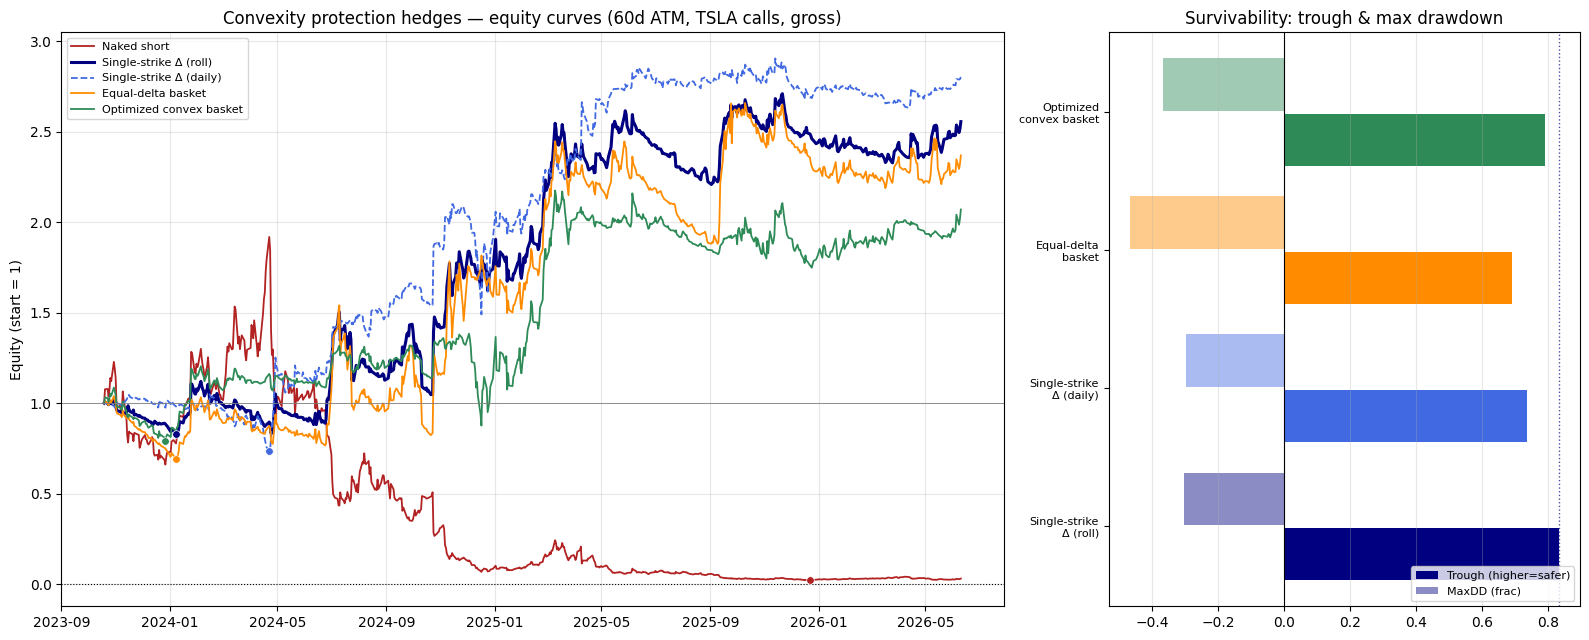

In [56]:
# ============================================================
# VISUALIZATION — Strategy 3 hedge comparison (5 approaches)
# ============================================================
curves = {
    "Naked short":             naked,
    "Single-strike Δ (roll)":  eq_roll,
    "Single-strike Δ (daily)": eq_daily,
    "Equal-delta basket":      eq_basket,
    "Optimized convex basket": eq_optbasket,
}

colors = {
    "Naked short":             "firebrick",
    "Single-strike Δ (roll)":  "navy",
    "Single-strike Δ (daily)": "royalblue",
    "Equal-delta basket":      "darkorange",
    "Optimized convex basket": "seagreen",
}

def _metrics(eq):
    eq = eq.dropna()
    return round(eq.min(),3), round((eq/eq.cummax()-1).min()*100,1), round((eq.iloc[-1]-1)*100,1)

summary = pd.DataFrame(
    {n: dict(zip(["Trough","MaxDD %","Return %"], _metrics(eq))) for n, eq in curves.items()}
).T
print(summary.to_string())

fig, ax = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={"width_ratios": [2, 1]})

# --- Panel 1: equity curves ---
for name, eq in curves.items():
    lw = 2.2 if name == "Single-strike Δ (roll)" else 1.3
    ls = "--" if "daily" in name else "-"
    ax[0].plot(eq.index, eq, color=colors[name], lw=lw, ls=ls, label=name)
    tr_date = eq.dropna().idxmin()
    ax[0].scatter([tr_date], [eq.min()], color=colors[name], s=30, zorder=5, edgecolor="white", linewidth=0.5)
ax[0].axhline(1.0, color="grey", lw=0.6)
ax[0].axhline(0.0, color="black", lw=0.8, ls=":")
ax[0].set_title("Convexity protection hedges — equity curves (60d ATM, TSLA calls, gross)")
ax[0].set_ylabel("Equity (start = 1)")
ax[0].legend(fontsize=8, loc="upper left"); ax[0].grid(alpha=0.3)

# --- Panel 2: trough & maxDD bars (hedged variants only) ---
names = [n for n in curves if n != "Naked short"]
troughs = [summary.loc[n, "Trough"] for n in names]
mdds    = [summary.loc[n, "MaxDD %"] / 100 for n in names]
y = np.arange(len(names))
ax[1].barh(y - 0.2, troughs, height=0.38, color=[colors[n] for n in names], label="Trough (higher=safer)")
ax[1].barh(y + 0.2, mdds, height=0.38, color=[colors[n] for n in names], alpha=0.45, label="MaxDD (frac)")
ax[1].axvline(0, color="black", lw=0.8)
ax[1].axvline(summary.loc["Single-strike Δ (roll)", "Trough"], color="navy", ls=":", lw=1, alpha=0.7)
ax[1].set_yticks(y); ax[1].set_yticklabels([n.replace(" ", "\n", 1) for n in names], fontsize=8)
ax[1].set_title("Survivability: trough & max drawdown")
ax[1].legend(fontsize=8, loc="lower right"); ax[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("strategy3_delta_basket_comparison.png", dpi=130)
plt.show()

## Using a combination of long and short dated options

In [58]:
# ============================================================
# TWO-MATURITY SCENARIO OPTIMIZER  (long-dated + short-dated legs)
# At each roll: given a (K_short, K_long) pair, solve for share split
#   min  cost   s.t.  payoff at each scenario >= convex short loss
# Scenarios evaluated at the SHORT leg's expiry:
#   short leg -> intrinsic (it expires)
#   long  leg -> Black-Scholes value with remaining time (still alive)
# ============================================================

def leg_value_at_scenario(S_scen, K, T_remaining, sigma, r=RISK_FREE):
    """Value of a call at scenario spot. If T_remaining<=0 -> intrinsic."""
    if T_remaining <= 1e-6:
        return max(S_scen - K, 0.0)
    return bs_call_price(S_scen, K, T_remaining, r, sigma)


def optimize_two_leg(day_chain, S, exp_short, exp_long, K_short, K_long,
                     d, scenarios=SCENARIOS, r=RISK_FREE):
    """Solve share split between one short-dated and one long-dated call."""
    row_s = day_chain[(day_chain["expiry"] == exp_short) & (day_chain["strike"] == K_short)]
    row_l = day_chain[(day_chain["expiry"] == exp_long)  & (day_chain["strike"] == K_long)]
    if row_s.empty or row_l.empty:
        return None
    px_s = float(row_s["px_last"].iloc[0]); px_l = float(row_l["px_last"].iloc[0])

    T_s = (exp_short - d).days / 365.0
    T_l = (exp_long  - d).days / 365.0
    T_remaining_long = T_l - T_s                      # long leg's life left at short's expiry

    # IVs today (assume surface unchanged at the scenario horizon)
    iv_s = implied_vol(px_s, S, K_short, T_s, r)
    iv_l = implied_vol(px_l, S, K_long,  T_l, r)
    if np.isnan(iv_l):
        iv_l = 0.60                                   # fallback if inversion fails

    # payoff matrix: rows = scenarios, cols = [short, long]
    payoff = []
    for m in scenarios:
        S_scen = S * (1 + m)
        v_short = max(S_scen - K_short, 0.0)                              # expires
        v_long  = leg_value_at_scenario(S_scen, K_long, T_remaining_long, iv_l, r)
        payoff.append([v_short, v_long])
    payoff = np.array(payoff)
    loss = np.array([convex_short_loss(m) for m in scenarios])

    res = linprog(c=[px_s, px_l], A_ub=-payoff, b_ub=-loss,
                  bounds=[(0, None), (0, None)], method="highs")
    if not res.success:
        return None
    n = res.x
    return {
        "n_short": n[0], "n_long": n[1],
        "px_short": px_s, "px_long": px_l,
        "cost_short": n[0]*px_s, "cost_long": n[1]*px_l,
        "total_premium": float(np.array([px_s, px_l]) @ n),
        "coverage": payoff @ n, "loss": loss,
        "iv_short": iv_s, "iv_long": iv_l,
        "T_remaining_long": T_remaining_long,
    }


# --- TEST on one date, sweeping strike combinations ---
d0 = pd.Timestamp("2024-06-03")
S0 = px3[UNDER].loc[d0]
chain0 = opt[opt["date"] == d0]

exps = chain0["expiry"].unique()
exp_short = pd.Timestamp(min(exps, key=lambda e: abs(((pd.Timestamp(e)-d0).days) - 60)))
exp_long  = pd.Timestamp(min(exps, key=lambda e: abs(((pd.Timestamp(e)-d0).days) - 180)))
print(f"Date {d0.date()}  spot {S0:.2f}")
print(f"Short expiry {exp_short.date()} ({(exp_short-d0).days}d) | "
      f"Long expiry {exp_long.date()} ({(exp_long-d0).days}d)\n")

def nearest_strike(chain, expiry, target):
    sub = chain[chain["expiry"] == expiry]
    return float(sub.iloc[(sub["strike"]-target).abs().argsort().iloc[0]]["strike"])

# sweep: short leg moneyness x long leg moneyness
short_mnys = [0.0, 0.10]
long_mnys  = [0.0, 0.10, 0.20]

rows = []
for ms in short_mnys:
    for ml in long_mnys:
        Ks = nearest_strike(chain0, exp_short, S0*(1+ms))
        Kl = nearest_strike(chain0, exp_long,  S0*(1+ml))
        sol = optimize_two_leg(chain0, S0, exp_short, exp_long, Ks, Kl, d0)
        if sol is None: continue
        rows.append({
            "short": f"{int(ms*100)}%OTM K={Ks:.0f}",
            "long":  f"{int(ml*100)}%OTM K={Kl:.0f}",
            "n_short": round(sol["n_short"], 4),
            "n_long":  round(sol["n_long"], 4),
            "cost_short": round(sol["cost_short"], 3),
            "cost_long":  round(sol["cost_long"], 3),
            "total_prem": round(sol["total_premium"], 3),
            "long_share_%": round(100*sol["cost_long"]/sol["total_premium"], 1),
        })
print(pd.DataFrame(rows).to_string(index=False))

Date 2024-06-03  spot 176.29
Short expiry 2024-07-19 (46d) | Long expiry 2024-11-15 (165d)

       short         long  n_short  n_long  cost_short  cost_long  total_prem  long_share_%
 0%OTM K=175  0%OTM K=175   0.0134  0.0000       0.182      0.000       0.182           0.0
 0%OTM K=175 10%OTM K=195   0.0134  0.0000       0.182      0.000       0.182           0.0
 0%OTM K=175 20%OTM K=210   0.0134  0.0000       0.182      0.000       0.182           0.0
10%OTM K=195  0%OTM K=175   0.0093  0.0061       0.057      0.165       0.221          74.4
10%OTM K=195 10%OTM K=195   0.0080  0.0089       0.049      0.166       0.215          77.4
10%OTM K=195 20%OTM K=210   0.0072  0.0119       0.044      0.169       0.213          79.5


In [59]:
# ============================================================
# STAGGERED TWO-LEG HEDGE — long-dated core + short-dated satellite
# Each leg rolls on its OWN clock. Delta target split by w_long (swept).
# ============================================================

def _select_contract(day_opts, d, S, target_dte, moneyness, roll_buffer=20, max_dte_mult=2.0):
    dte_all = (day_opts["expiry"] - d).dt.days
    pool = day_opts[(dte_all > roll_buffer) & (dte_all <= max_dte_mult*target_dte)]["expiry"].unique()
    if len(pool) == 0:
        return None
    tgt = d + pd.Timedelta(days=target_dte)
    ce = pd.Timestamp(min(pool, key=lambda e: abs((pd.Timestamp(e) - tgt).days)))
    ex = day_opts[day_opts["expiry"] == ce]
    K = float(ex.iloc[(ex["strike"] - S*(1+moneyness)).abs().argsort().iloc[0]]["strike"])
    return ce, K


def run_two_leg_backtest(opt_table, spot, w_long,
                         dte_short=60, dte_long=180,
                         mny_short=0.0, mny_long=0.20,
                         target_delta=2.0, borrow_tslt=0.0,
                         roll_buffer=20, max_dte_mult=2.0, r=RISK_FREE):
    dates = spot.index
    tslt_g = px3[LETF].reindex(dates) / px3[LETF].reindex(dates).iloc[0]
    cum_short_pnl = -(tslt_g - 1.0)

    legs = {
        "short": {"exp": None, "K": None, "sh": 0.0, "dte": dte_short,
                  "mny": mny_short, "w": 1.0 - w_long, "rolls": 0},
        "long":  {"exp": None, "K": None, "sh": 0.0, "dte": dte_long,
                  "mny": mny_long,  "w": w_long,       "rolls": 0},
    }
    cash_opt = cum_borrow = 0.0
    prem_paid_tot = prem_recd_tot = 0.0
    equity = pd.Series(index=dates, dtype=float)

    for j, d in enumerate(dates):
        S = spot.loc[d]
        day_opts = opt_table[opt_table["date"] == d]

        if not day_opts.empty:
            for name, L in legs.items():
                if L["w"] <= 1e-9:                     # leg not used at this split
                    continue
                need = L["exp"] is None or (L["exp"] - d).days <= roll_buffer
                if not need:
                    continue
                sel = _select_contract(day_opts, d, S, L["dte"], L["mny"], roll_buffer, max_dte_mult)
                if sel is None:
                    continue
                new_exp, new_K = sel
                # sell this leg's existing position
                if L["exp"] is not None and L["sh"] > 0:
                    opx = _price_of(opt_table, d, (L["exp"], L["K"]))
                    if not np.isnan(opx):
                        cash_opt += L["sh"] * opx
                        prem_recd_tot += L["sh"] * opx
                # buy new, sized to THIS leg's share of the delta target
                npx, ndelta = _iv_delta_for(opt_table, d, S, (new_exp, new_K), r)
                if np.isnan(npx):
                    continue
                if np.isnan(ndelta) or ndelta <= 1e-6:
                    ndelta = 1.0 if S > new_K else 0.01
                sh = (L["w"] * target_delta) / (ndelta * S)
                cash_opt -= sh * npx
                prem_paid_tot += sh * npx
                L.update({"exp": new_exp, "K": new_K, "sh": sh})
                L["rolls"] += 1

        # mark both legs to market
        pos_val = 0.0
        for L in legs.values():
            if L["exp"] is None or L["sh"] <= 0:
                continue
            px = _price_of(opt_table, d, (L["exp"], L["K"]))
            if np.isnan(px):
                px = max(S - L["K"], 0.0)
            pos_val += L["sh"] * px

        cum_borrow += tslt_g.iloc[j] * borrow_tslt / 252
        equity.iloc[j] = 1.0 + cum_short_pnl.iloc[j] + (cash_opt + pos_val) - cum_borrow

    return equity, {"prem_paid": prem_paid_tot, "prem_recd": prem_recd_tot,
                    "rolls_short": legs["short"]["rolls"], "rolls_long": legs["long"]["rolls"]}


# --- sweep the split: 0% long (pure short-dated) -> 100% long ---
splits = [0.0, 0.25, 0.50, 0.75, 1.0]
rows = []
for w in splits:
    eq, info = run_two_leg_backtest(opt, spot_tsla, w_long=w,
                                    dte_short=60, dte_long=180,
                                    mny_short=0.0, mny_long=0.20)
    eq = eq.dropna()
    rows.append({
        "w_long": w,
        "Trough": round(eq.min(), 3),
        "MaxDD %": round((eq/eq.cummax() - 1).min()*100, 1),
        "Return %": round((eq.iloc[-1]-1)*100, 1),
        "Net drag": round(info["prem_paid"] - info["prem_recd"], 3),
        "rolls_S": info["rolls_short"],
        "rolls_L": info["rolls_long"],
    })
print("STAGGERED TWO-LEG HEDGE — split sweep")
print("short leg: 60d ATM | long leg: 180d 20% OTM | gross of borrow\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nBenchmark — single-strike 60d ATM delta-matched (roll): trough 0.832, maxDD -30.4%")

STAGGERED TWO-LEG HEDGE — split sweep
short leg: 60d ATM | long leg: 180d 20% OTM | gross of borrow

 w_long  Trough  MaxDD %  Return %  Net drag  rolls_S  rolls_L
   0.00   0.832    -30.4     155.5    -1.312       29        0
   0.25   0.838    -40.0     158.2    -1.354       29        7
   0.50   0.800    -55.2     160.8    -1.397       29        7
   0.75   0.612    -68.2     163.5    -1.439       29        7
   1.00   0.425    -79.5     166.1    -1.482        0        7

Benchmark — single-strike 60d ATM delta-matched (roll): trough 0.832, maxDD -30.4%


In [60]:
# --- Strike combination sweep for the staggered structure ---
combos = []
for w in [0.25, 0.50]:
    for ms in [0.0, 0.10]:
        for ml in [0.0, 0.10, 0.20]:
            eq, info = run_two_leg_backtest(opt, spot_tsla, w_long=w,
                                            dte_short=60, dte_long=180,
                                            mny_short=ms, mny_long=ml)
            eq = eq.dropna()
            combos.append({
                "w_long": w,
                "short": "ATM" if ms == 0 else f"{int(ms*100)}%OTM",
                "long":  "ATM" if ml == 0 else f"{int(ml*100)}%OTM",
                "Trough": round(eq.min(), 3),
                "MaxDD %": round((eq/eq.cummax()-1).min()*100, 1),
                "Return %": round((eq.iloc[-1]-1)*100, 1),
                "Net drag": round(info["prem_paid"]-info["prem_recd"], 3),
            })

res = pd.DataFrame(combos)
print("STAGGERED HEDGE — strike combination sweep (60d short / 180d long, gross)\n")
print(res.to_string(index=False))
print("\nBenchmark (single-strike 60d ATM delta-matched): trough 0.832, maxDD -30.4%")
print(f"\nBest trough: {res.loc[res['Trough'].idxmax()].to_dict()}")

STAGGERED HEDGE — strike combination sweep (60d short / 180d long, gross)

 w_long  short   long  Trough  MaxDD %  Return %  Net drag
   0.25    ATM    ATM   0.841    -32.8     158.4    -1.287
   0.25    ATM 10%OTM   0.843    -36.7     160.9    -1.324
   0.25    ATM 20%OTM   0.838    -40.0     158.2    -1.354
   0.25 10%OTM    ATM   0.736    -44.5     148.3    -1.199
   0.25 10%OTM 10%OTM   0.726    -48.2     150.8    -1.235
   0.25 10%OTM 20%OTM   0.721    -51.1     148.0    -1.265
   0.50    ATM    ATM   0.848    -37.4     161.4    -1.263
   0.50    ATM 10%OTM   0.852    -42.6     166.4    -1.336
   0.50    ATM 20%OTM   0.800    -55.2     160.8    -1.397
   0.50 10%OTM    ATM   0.797    -43.1     154.6    -1.204
   0.50 10%OTM 10%OTM   0.776    -49.6     159.6    -1.277
   0.50 10%OTM 20%OTM   0.719    -60.1     154.0    -1.338

Benchmark (single-strike 60d ATM delta-matched): trough 0.832, maxDD -30.4%

Best trough: {'w_long': 0.5, 'short': 'ATM', 'long': '10%OTM', 'Trough': 0.852, 

In [61]:
# --- Long-leg maturity sweep (short leg fixed at 60d ATM) ---
rows = []
for dl in [90, 180, 270]:
    for ml in [0.0, 0.10]:
        for w in [0.25, 0.50]:
            eq, info = run_two_leg_backtest(opt, spot_tsla, w_long=w,
                                            dte_short=60, dte_long=dl,
                                            mny_short=0.0, mny_long=ml)
            eq = eq.dropna()
            rows.append({
                "long_DTE": dl,
                "long_mny": "ATM" if ml == 0 else f"{int(ml*100)}%OTM",
                "w_long": w,
                "Trough": round(eq.min(), 3),
                "MaxDD %": round((eq/eq.cummax()-1).min()*100, 1),
                "Return %": round((eq.iloc[-1]-1)*100, 1),
                "Net drag": round(info["prem_paid"]-info["prem_recd"], 3),
                "rolls_L": info["rolls_long"],
            })

res = pd.DataFrame(rows).sort_values("Trough", ascending=False)
print("STAGGERED HEDGE — long-leg maturity sweep (short leg: 60d ATM, gross)\n")
print(res.to_string(index=False))
print("\nBenchmark (single-strike 60d ATM delta-matched): trough 0.832, maxDD -30.4%")

best = res.iloc[0]
print(f"\nBest trough: long {best['long_DTE']}d {best['long_mny']}, w_long={best['w_long']} "
      f"-> trough {best['Trough']}, maxDD {best['MaxDD %']}%")

# pivot for readability
print("\n--- TROUGH by long-leg maturity and weight ---")
print(res.pivot_table(index=["long_mny","w_long"], columns="long_DTE", values="Trough").to_string())
print("\n--- MAXDD % by long-leg maturity and weight ---")
print(res.pivot_table(index=["long_mny","w_long"], columns="long_DTE", values="MaxDD %").to_string())

STAGGERED HEDGE — long-leg maturity sweep (short leg: 60d ATM, gross)

 long_DTE long_mny  w_long  Trough  MaxDD %  Return %  Net drag  rolls_L
      270   10%OTM    0.50   0.862    -40.3     161.8    -1.400        4
      270      ATM    0.50   0.860    -38.8     159.8    -1.373        4
      180   10%OTM    0.50   0.852    -42.6     166.4    -1.336        7
       90      ATM    0.25   0.849    -33.1     151.9    -1.230       16
       90      ATM    0.50   0.848    -36.2     148.2    -1.147       16
      180      ATM    0.50   0.848    -37.4     161.4    -1.263        7
      270   10%OTM    0.25   0.848    -33.3     158.7    -1.356        4
      270      ATM    0.25   0.846    -33.6     157.7    -1.343        4
      180   10%OTM    0.25   0.843    -36.7     160.9    -1.324        7
      180      ATM    0.25   0.841    -32.8     158.4    -1.287        7
       90   10%OTM    0.25   0.815    -37.1     152.4    -1.255       16
       90   10%OTM    0.50   0.717    -44.9     149.3

In [62]:
BM_TROUGH, BM_MAXDD = 0.832, -30.4          # single-strike benchmark
dte_color = {90: "#2a9d8f", 180: "#e76f51", 270: "#264653"}
w_marker  = {0.25: "o", 0.50: "s"}
from matplotlib.lines import Line2D

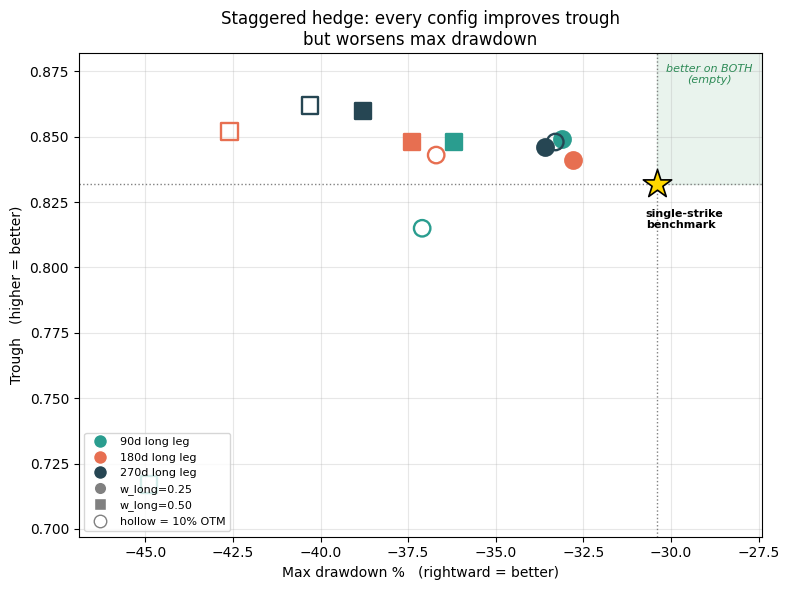

In [63]:
fig, ax0 = plt.subplots(figsize=(8, 6))

for _, r in res.iterrows():
    filled = (r["long_mny"] == "ATM")
    ax0.scatter(r["MaxDD %"], r["Trough"], marker=w_marker[r["w_long"]], s=140,
                facecolor=dte_color[r["long_DTE"]] if filled else "none",
                edgecolor=dte_color[r["long_DTE"]], linewidth=1.7, zorder=3)

ax0.scatter([BM_MAXDD], [BM_TROUGH], marker="*", s=460, color="gold",
            edgecolor="black", linewidth=1.2, zorder=5)
ax0.annotate("single-strike\nbenchmark", (BM_MAXDD, BM_TROUGH), fontsize=8,
             fontweight="bold", xytext=(-8, -32), textcoords="offset points")

xlo, xhi = res["MaxDD %"].min() - 2, BM_MAXDD + 3
ylo, yhi = res["Trough"].min() - 0.02, res["Trough"].max() + 0.02
ax0.set_xlim(xlo, xhi); ax0.set_ylim(ylo, yhi)
ax0.fill_between([BM_MAXDD, xhi], BM_TROUGH, yhi, color="seagreen", alpha=0.10, zorder=0)
ax0.text((BM_MAXDD + xhi)/2, yhi - 0.004, "better on BOTH\n(empty)", fontsize=8,
         ha="center", va="top", color="seagreen", style="italic")
ax0.axhline(BM_TROUGH, color="grey", ls=":", lw=1)
ax0.axvline(BM_MAXDD,  color="grey", ls=":", lw=1)
ax0.set_xlabel("Max drawdown %   (rightward = better)")
ax0.set_ylabel("Trough   (higher = better)")
ax0.set_title("Staggered hedge: every config improves trough\nbut worsens max drawdown")
ax0.grid(alpha=0.3)

leg = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=10, label=f'{d}d long leg')
       for d, c in dte_color.items()]
leg += [Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=9, label='w_long=0.25'),
        Line2D([0],[0], marker='s', color='w', markerfacecolor='grey', markersize=9, label='w_long=0.50'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='none', markeredgecolor='grey', markersize=9, label='hollow = 10% OTM')]
ax0.legend(handles=leg, fontsize=8, loc="lower left")

plt.tight_layout()
plt.savefig("staggered_panelA_tradeoff.png", dpi=130)
plt.show()

C:\Users\balod\AppData\Local\Temp\ipykernel_38624\4013299352.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot(grp["long_DTE"], grp["Trough"], "o-",


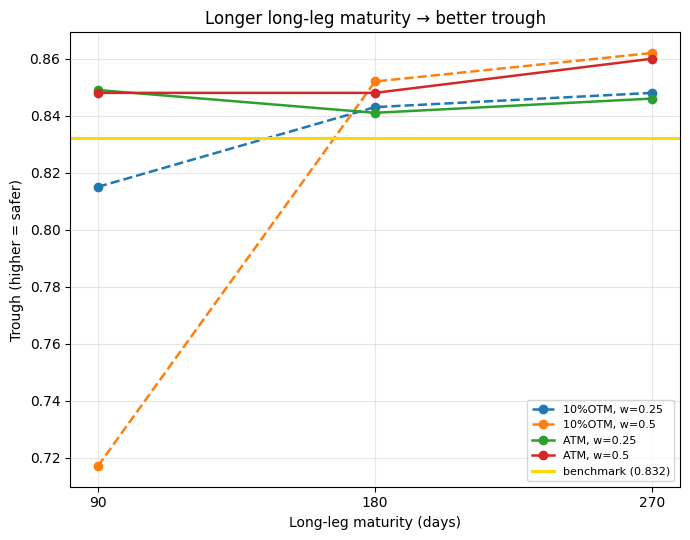

In [64]:
fig, ax1 = plt.subplots(figsize=(7, 5.5))

for (mny, w), grp in res.groupby(["long_mny", "w_long"]):
    grp = grp.sort_values("long_DTE")
    ax1.plot(grp["long_DTE"], grp["Trough"], "o-",
             ls="-" if mny == "ATM" else "--",
             lw=1.8, label=f"{mny}, w={w}")

ax1.axhline(BM_TROUGH, color="gold", lw=2.2, label="benchmark (0.832)")
ax1.set_xticks([90, 180, 270])
ax1.set_xlabel("Long-leg maturity (days)")
ax1.set_ylabel("Trough (higher = safer)")
ax1.set_title("Longer long-leg maturity → better trough")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("staggered_panelB_maturity.png", dpi=130)
plt.show()

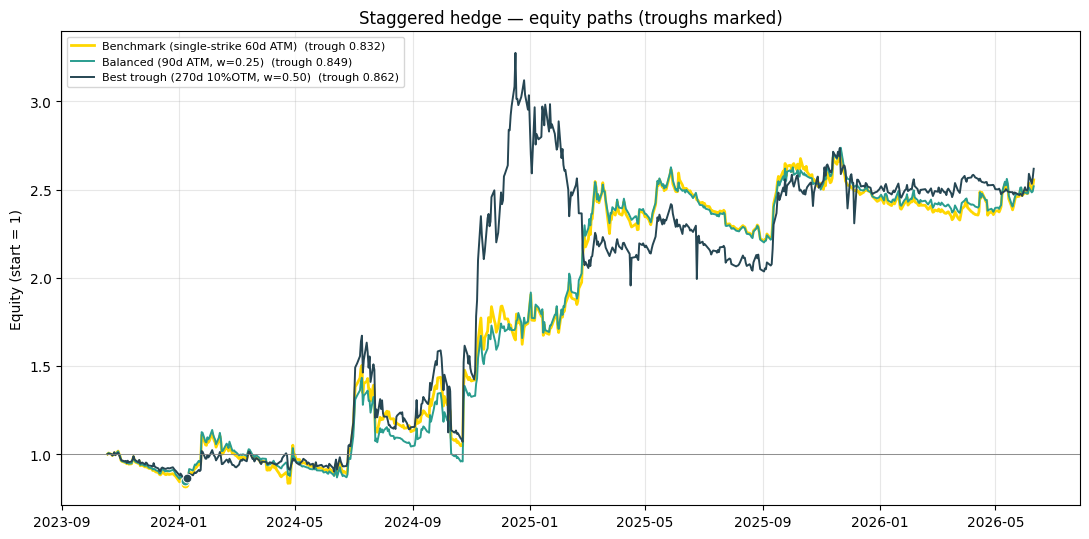

In [65]:
fig, ax2 = plt.subplots(figsize=(11, 5.5))

runs = {
    "Benchmark (single-strike 60d ATM)": dict(w_long=0.0,  dte_long=180, mny_long=0.0),
    "Balanced (90d ATM, w=0.25)":        dict(w_long=0.25, dte_long=90,  mny_long=0.0),
    "Best trough (270d 10%OTM, w=0.50)": dict(w_long=0.50, dte_long=270, mny_long=0.10),
}
cols = {"Benchmark (single-strike 60d ATM)": "gold",
        "Balanced (90d ATM, w=0.25)":        "#2a9d8f",
        "Best trough (270d 10%OTM, w=0.50)": "#264653"}

for name, kw in runs.items():
    eq, _ = run_two_leg_backtest(opt, spot_tsla, dte_short=60, mny_short=0.0, **kw)
    eq = eq.dropna()
    ax2.plot(eq.index, eq, lw=2.0 if "Benchmark" in name else 1.4,
             color=cols[name], label=f"{name}  (trough {eq.min():.3f})")
    ax2.scatter([eq.idxmin()], [eq.min()], color=cols[name], s=40,
                edgecolor="white", linewidth=0.7, zorder=5)

ax2.axhline(1.0, color="grey", lw=0.6)
ax2.set_ylabel("Equity (start = 1)")
ax2.set_title("Staggered hedge — equity paths (troughs marked)")
ax2.legend(fontsize=8, loc="upper left"); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("staggered_panelC_equity.png", dpi=130)
plt.show()

In [124]:
# ============================================================
# PROJECT SUMMARY TABLE — CAGR, Trough, MaxDD, Sharpe, Calmar
# ============================================================
def _stats(eq, rf=0.0, periods=252):
    eq = eq.dropna()
    n = len(eq)
    rets = eq.pct_change().dropna()

    total = eq.iloc[-1] / eq.iloc[0]
    cagr = (total ** (periods / n) - 1) if total > 0 else np.nan

    ann_vol = rets.std() * np.sqrt(periods)
    sharpe = (cagr - rf) / ann_vol if (ann_vol > 0 and not np.isnan(cagr)) else np.nan

    mdd = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(mdd) if (mdd < 0 and not np.isnan(cagr)) else np.nan

    return (round(cagr*100, 1) if not np.isnan(cagr) else np.nan,
            round(eq.min(), 3),
            round(mdd*100, 1),
            round(sharpe, 2) if not np.isnan(sharpe) else np.nan,
            round(calmar, 2) if not np.isnan(calmar) else np.nan,
            n)

progression = [
    ("Baseline",       "Static short TSLT (naked)",                    naked_test),
    ("Fixed notional", "Short + 60d ATM call, 2x notional",            eq_s3),
    ("Delta-matched",  "Short + 60d ATM call, delta-matched (roll)",   eq_roll),
    ("Delta-matched",  "Short + 60d ATM call, delta-matched (daily)",  eq_daily),
    ("Basket",         "Equal-delta basket (guessed weights)",         eq_basket),
    ("Basket",         "Scenario-optimized convex basket",             eq_optbasket),
]

rows = []
for stage, name, eq in progression:
    c, t, m, s, k, n = _stats(eq)
    rows.append({"Stage": stage, "Strategy": name, "CAGR %": c, "Trough": t,
                 "Max Drawdown %": m, "Sharpe": s, "Calmar": k, "Days": n})

staggered = [
    ("Staggered", "Two-leg: 60d ATM + 90d ATM (w=0.25)",     dict(w_long=0.25, dte_long=90,  mny_long=0.0)),
    ("Staggered", "Two-leg: 60d ATM + 270d 10%OTM (w=0.50)", dict(w_long=0.50, dte_long=270, mny_long=0.10)),
]
for stage, name, kw in staggered:
    eq, _ = run_two_leg_backtest(opt, spot_tsla, dte_short=60, mny_short=0.0, **kw)
    c, t, m, s, k, n = _stats(eq)
    rows.append({"Stage": stage, "Strategy": name, "CAGR %": c, "Trough": t,
                 "Max Drawdown %": m, "Sharpe": s, "Calmar": k, "Days": n})

summary_table = pd.DataFrame(rows)
print("PROJECT PROGRESSION — Strategy 3 (60d base, TSLA calls, gross of borrow, rf=0)\n")
print(summary_table.to_string(index=False))

summary_table.to_csv("project_progression_summary.csv", index=False)
print("\n--- markdown (for slides) ---")
print(summary_table.drop(columns="Days").to_markdown(index=False))

PROJECT PROGRESSION — Strategy 3 (60d base, TSLA calls, gross of borrow, rf=0)

         Stage                                    Strategy  CAGR %  Trough  Max Drawdown %  Sharpe  Calmar  Days
      Baseline                   Static short TSLT (naked)     6.5  -0.688          -141.6    0.01    0.05   662
Fixed notional           Short + 60d ATM call, 2x notional    28.4   0.603           -55.7    0.49    0.51   662
 Delta-matched  Short + 60d ATM call, delta-matched (roll)    42.9   0.832           -30.4    0.90    1.41   662
 Delta-matched Short + 60d ATM call, delta-matched (daily)    48.0   0.736           -29.8    1.06    1.61   662
        Basket        Equal-delta basket (guessed weights)    38.9   0.692           -46.6    0.62    0.83   662
        Basket            Scenario-optimized convex basket    31.9   0.791           -36.7    0.72    0.87   662
     Staggered         Two-leg: 60d ATM + 90d ATM (w=0.25)    42.1   0.849           -33.1    0.92    1.27   662
     Staggered  